In [1]:
import pandas as pd
import missingno as msno
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('2016_Building_Energy_Benchmarking.csv')

In [3]:
df

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,...,Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,...,1.156514e+06,3.946027e+06,12764.529300,1.276453e+06,False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,...,9.504252e+05,3.242851e+06,51450.816410,5.145082e+06,False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,...,1.451544e+07,4.952666e+07,14938.000000,1.493800e+06,False,NaN,Compliant,NaN,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,...,8.115253e+05,2.768924e+06,18112.130860,1.811213e+06,False,NaN,Compliant,NaN,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,...,1.573449e+06,5.368607e+06,88039.984380,8.803998e+06,False,NaN,Compliant,NaN,505.01,2.88
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3371,50222,2016,Nonresidential COS,Office,Horticulture building,1600 S Dakota St,Seattle,WA,NaN,1624049080,...,1.536550e+05,5.242709e+05,3254.750244,3.254750e+05,True,NaN,Error - Correct Default Data,NaN,20.94,1.70
3372,50223,2016,Nonresidential COS,Other,International district/Chinatown CC,719 8th Ave S,Seattle,WA,NaN,3558300000,...,1.162210e+05,3.965461e+05,5537.299805,5.537300e+05,False,NaN,Compliant,NaN,32.17,2.01
3373,50224,2016,Nonresidential COS,Other,Queen Anne Pool,1920 1st Ave W,Seattle,WA,NaN,1794501150,...,5.252517e+05,1.792159e+06,39737.390630,3.973739e+06,False,NaN,Compliant,NaN,223.54,16.99
3374,50225,2016,Nonresidential COS,Mixed Use Property,South Park Community Center,8319 8th Ave S,Seattle,WA,NaN,7883603155,...,1.022480e+05,3.488702e+05,3706.010010,3.706010e+05,False,NaN,Compliant,NaN,22.11,1.57


In [4]:
df.columns

Index(['OSEBuildingID', 'DataYear', 'BuildingType', 'PrimaryPropertyType',
       'PropertyName', 'Address', 'City', 'State', 'ZipCode',
       'TaxParcelIdentificationNumber', 'CouncilDistrictCode', 'Neighborhood',
       'Latitude', 'Longitude', 'YearBuilt', 'NumberofBuildings',
       'NumberofFloors', 'PropertyGFATotal', 'PropertyGFAParking',
       'PropertyGFABuilding(s)', 'ListOfAllPropertyUseTypes',
       'LargestPropertyUseType', 'LargestPropertyUseTypeGFA',
       'SecondLargestPropertyUseType', 'SecondLargestPropertyUseTypeGFA',
       'ThirdLargestPropertyUseType', 'ThirdLargestPropertyUseTypeGFA',
       'YearsENERGYSTARCertified', 'ENERGYSTARScore', 'SiteEUI(kBtu/sf)',
       'SiteEUIWN(kBtu/sf)', 'SourceEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)',
       'SiteEnergyUse(kBtu)', 'SiteEnergyUseWN(kBtu)', 'SteamUse(kBtu)',
       'Electricity(kWh)', 'Electricity(kBtu)', 'NaturalGas(therms)',
       'NaturalGas(kBtu)', 'DefaultData', 'Comments', 'ComplianceStatus',
       'Outlier

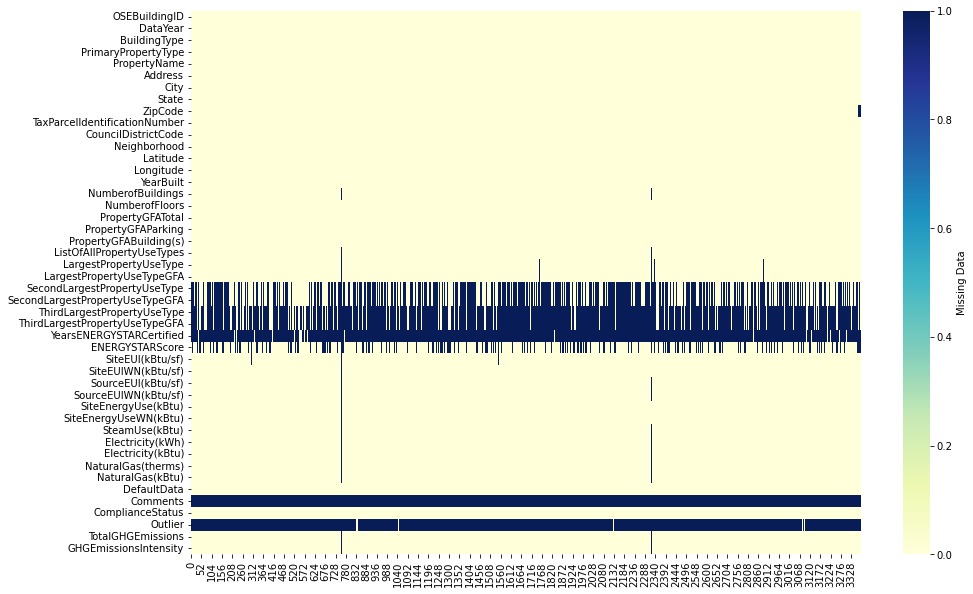

In [5]:
plt.figure(figsize=(15,10))
sns.heatmap(df.isna().transpose(),
            cmap="YlGnBu",
            cbar_kws={'label': 'Missing Data'})
plt.savefig("missing_data_with_heatmap_Seaborn_Python.png", dpi=100)

Le dataset est plutôt bien rempli
- Beaucoup de colonnes sans données manquantes
- Quelques colonnes peu remplies :
    - Second et ThirdLargestPropertyUseType(GFA)
    - ENERGYSTARScore
    - YearsENERGYSTARScoreCertified
    - Comments et Outlier
- Quelques lignes avec peu de données

In [6]:
df['BuildingType'].value_counts()

NonResidential          1460
Multifamily LR (1-4)    1018
Multifamily MR (5-9)     580
Multifamily HR (10+)     110
SPS-District K-12         98
Nonresidential COS        85
Campus                    24
Nonresidential WA          1
Name: BuildingType, dtype: int64

Le sujet nous indique nous souhaitons pouvoir prédire les données pour des bâtiments non résidentiel donc on ne conserve que ce type de bâtiment

In [7]:
# Sélectionner les building type == non residential
non_residential_buildings = ['NonResidential', 'Nonresidential COS', 'Nonresidential WA']
df_non_residential = df.loc[df['BuildingType'].isin(non_residential_buildings)]

In [8]:
df_non_residential.shape

(1546, 46)

In [9]:
#Compliance status ne garder que compliant data
df_non_residential.loc[df_non_residential['ComplianceStatus'] != 'Compliant']

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,...,Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
226,350,2016,NonResidential,Large Office,Second And Spring Building,1100 Second Avenue,Seattle,WA,98101.0,0942000045,...,1.166315e+07,3.979467e+07,16048.309570,1.604831e+06,False,NaN,Non-Compliant,High outlier,362.66,2.10
276,405,2016,NonResidential,Large Office,The Decatur,1511 6th Avenue,Seattle,WA,98101.0,1975700125,...,1.770166e+06,6.039805e+06,9574.279297,9.574280e+05,True,NaN,Error - Correct Default Data,NaN,148.11,1.16
304,435,2016,NonResidential,Other,Washington State Convention Center,705 Pike St,Seattle,WA,98101.0,1978200105,...,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,False,NaN,Non-Compliant,NaN,0.00,0.00
384,539,2016,NonResidential,Retail Store,University Center,4501 Roosevelt Way NE,Seattle,WA,98105.0,5335200380,...,9.348260e+04,3.189630e+05,0.000000,0.000000e+00,False,NaN,Non-Compliant,Low outlier,2.22,0.03
448,608,2016,NonResidential,Large Office,411 1ST AVE S (ID608),411 1ST AVE S,Seattle,WA,98104.0,5247800200,...,4.715030e+05,1.608768e+06,3430.500488,3.430500e+05,False,NaN,Non-Compliant,Low outlier,29.43,0.19
457,618,2016,NonResidential,Small- and Mid-Sized Office,Prefontaine,110 Prefontaine Pl S,Seattle,WA,98104.0,5247801045,...,9.414621e+05,3.212269e+06,0.000000,0.000000e+00,True,NaN,Error - Correct Default Data,NaN,22.39,0.30
517,704,2016,NonResidential,Large Office,401 Elliott Ave West,401 Elliot Ave West,Seattle,WA,98119.0,7666202110,...,7.953454e+06,2.713719e+07,0.000000,0.000000e+00,False,NaN,Non-Compliant,High outlier,189.18,1.46
578,773,2016,NonResidential,Small- and Mid-Sized Office,SEATTLE BUILDING,215 COLUMBIA ST,Seattle,WA,98104.0,0939000245,...,NaN,NaN,NaN,NaN,False,NaN,Non-Compliant,NaN,NaN,NaN
746,19776,2016,NonResidential,Other,Welcome Home Society - PriceCo,13537 Aurora Ave N,Seattle,WA,98133.0,0164000020,...,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,False,NaN,Missing Data,NaN,0.00,0.00
1045,20617,2016,NonResidential,Retail Store,Seattle Habitat Store,21 S Nevada St,Seattle,WA,98134.0,1824049074,...,1.436250e+04,4.900500e+04,964.640015,9.646400e+04,True,NaN,Error - Correct Default Data,Low outlier,5.46,0.14


In [10]:
selected_data = df_non_residential.loc[df_non_residential['ComplianceStatus'] == 'Compliant']

In [11]:
selected_data

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,...,Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,...,1.156514e+06,3.946027e+06,12764.529300,1.276453e+06,False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,...,9.504252e+05,3.242851e+06,51450.816410,5.145082e+06,False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,...,1.451544e+07,4.952666e+07,14938.000000,1.493800e+06,False,NaN,Compliant,NaN,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,...,8.115253e+05,2.768924e+06,18112.130860,1.811213e+06,False,NaN,Compliant,NaN,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,...,1.573449e+06,5.368607e+06,88039.984380,8.803998e+06,False,NaN,Compliant,NaN,505.01,2.88
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3370,50221,2016,Nonresidential COS,Other,High Point Community Center,6920 34th Ave SW,Seattle,WA,NaN,2524039059,...,1.853347e+05,6.323620e+05,2997.199951,2.997200e+05,False,NaN,Compliant,NaN,20.33,1.11
3372,50223,2016,Nonresidential COS,Other,International district/Chinatown CC,719 8th Ave S,Seattle,WA,NaN,3558300000,...,1.162210e+05,3.965461e+05,5537.299805,5.537300e+05,False,NaN,Compliant,NaN,32.17,2.01
3373,50224,2016,Nonresidential COS,Other,Queen Anne Pool,1920 1st Ave W,Seattle,WA,NaN,1794501150,...,5.252517e+05,1.792159e+06,39737.390630,3.973739e+06,False,NaN,Compliant,NaN,223.54,16.99
3374,50225,2016,Nonresidential COS,Mixed Use Property,South Park Community Center,8319 8th Ave S,Seattle,WA,NaN,7883603155,...,1.022480e+05,3.488702e+05,3706.010010,3.706010e+05,False,NaN,Compliant,NaN,22.11,1.57


In [12]:
# Vérifier l'absence de doublons
selected_data.loc[selected_data['OSEBuildingID'].duplicated(keep=False),:]

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,...,Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity


In [13]:
#Trouver les colonnes avec une seule valeur
selected_data.loc[:, selected_data.nunique() == 1]

,DataYear,City,State,DefaultData,ComplianceStatus
0,2016,Seattle,WA,False,Compliant
1,2016,Seattle,WA,False,Compliant
2,2016,Seattle,WA,False,Compliant
3,2016,Seattle,WA,False,Compliant
4,2016,Seattle,WA,False,Compliant
...,...,...,...,...,...
3370,2016,Seattle,WA,False,Compliant
3372,2016,Seattle,WA,False,Compliant
3373,2016,Seattle,WA,False,Compliant
3374,2016,Seattle,WA,False,Compliant


In [14]:
#Colonnes avec une seule valeur : 
#Outlier et Comments : que NaN donc à supprimer
del_list = ['DataYear', 'DefaultData', 'City', 'State', 'Outlier', 'ComplianceStatus', 'Comments']

In [15]:
#Supprimer les colonnes qui n'apportent pas d'information
selected_data = selected_data.drop(labels=del_list, axis=1)

In [16]:
selected_data

,OSEBuildingID,BuildingType,PrimaryPropertyType,PropertyName,Address,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,...,SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),TotalGHGEmissions,GHGEmissionsIntensity
0,1,NonResidential,Hotel,Mayflower park hotel,405 Olive way,98101.0,0659000030,7,DOWNTOWN,47.61220,...,189.000000,7.226362e+06,7.456910e+06,2003882.00,1.156514e+06,3.946027e+06,12764.529300,1.276453e+06,249.98,2.83
1,2,NonResidential,Hotel,Paramount Hotel,724 Pine street,98101.0,0659000220,7,DOWNTOWN,47.61317,...,179.399994,8.387933e+06,8.664479e+06,0.00,9.504252e+05,3.242851e+06,51450.816410,5.145082e+06,295.86,2.86
2,3,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,98101.0,0659000475,7,DOWNTOWN,47.61393,...,244.100006,7.258702e+07,7.393711e+07,21566554.00,1.451544e+07,4.952666e+07,14938.000000,1.493800e+06,2089.28,2.19
3,5,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,98101.0,0659000640,7,DOWNTOWN,47.61412,...,224.000000,6.794584e+06,6.946800e+06,2214446.25,8.115253e+05,2.768924e+06,18112.130860,1.811213e+06,286.43,4.67
4,8,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,98121.0,0659000970,7,DOWNTOWN,47.61375,...,215.600006,1.417261e+07,1.465650e+07,0.00,1.573449e+06,5.368607e+06,88039.984380,8.803998e+06,505.01,2.88
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3370,50221,Nonresidential COS,Other,High Point Community Center,6920 34th Ave SW,NaN,2524039059,1,DELRIDGE NEIGHBORHOODS,47.54067,...,136.600006,9.320821e+05,1.025432e+06,0.00,1.853347e+05,6.323620e+05,2997.199951,2.997200e+05,20.33,1.11
3372,50223,Nonresidential COS,Other,International district/Chinatown CC,719 8th Ave S,NaN,3558300000,2,DOWNTOWN,47.59625,...,118.900002,9.502762e+05,1.053706e+06,0.00,1.162210e+05,3.965461e+05,5537.299805,5.537300e+05,32.17,2.01
3373,50224,Nonresidential COS,Other,Queen Anne Pool,1920 1st Ave W,NaN,1794501150,7,MAGNOLIA / QUEEN ANNE,47.63644,...,767.799988,5.765898e+06,6.053764e+06,0.00,5.252517e+05,1.792159e+06,39737.390630,3.973739e+06,223.54,16.99
3374,50225,Nonresidential COS,Mixed Use Property,South Park Community Center,8319 8th Ave S,NaN,7883603155,1,GREATER DUWAMISH,47.52832,...,110.800003,7.194712e+05,7.828413e+05,0.00,1.022480e+05,3.488702e+05,3706.010010,3.706010e+05,22.11,1.57


In [17]:
selected_data.columns

Index(['OSEBuildingID', 'BuildingType', 'PrimaryPropertyType', 'PropertyName',
       'Address', 'ZipCode', 'TaxParcelIdentificationNumber',
       'CouncilDistrictCode', 'Neighborhood', 'Latitude', 'Longitude',
       'YearBuilt', 'NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal',
       'PropertyGFAParking', 'PropertyGFABuilding(s)',
       'ListOfAllPropertyUseTypes', 'LargestPropertyUseType',
       'LargestPropertyUseTypeGFA', 'SecondLargestPropertyUseType',
       'SecondLargestPropertyUseTypeGFA', 'ThirdLargestPropertyUseType',
       'ThirdLargestPropertyUseTypeGFA', 'YearsENERGYSTARCertified',
       'ENERGYSTARScore', 'SiteEUI(kBtu/sf)', 'SiteEUIWN(kBtu/sf)',
       'SourceEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)', 'SiteEnergyUse(kBtu)',
       'SiteEnergyUseWN(kBtu)', 'SteamUse(kBtu)', 'Electricity(kWh)',
       'Electricity(kBtu)', 'NaturalGas(therms)', 'NaturalGas(kBtu)',
       'TotalGHGEmissions', 'GHGEmissionsIntensity'],
      dtype='object')

- Buildingtype : différence entre les différents NR ? sinon à supp

- OSEBuildingID 'TaxParcelIdentificationNumber' : numéros d'identifications garder OSEBuildingID pour l'instant

- Transformer YearBuilt en Age et supprimer YearBuilt

- Données géographiques : 
    - catégories : 'ZipCode' 'Neighborhood', 'CouncilDistrictCode'
    - précises : 'Address' 'Latitude', 'Longitude'  

- Données du batiment : 'NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal', 'PropertyGFAParking', 'PropertyGFABuilding(s)', 'ListOfAllPropertyUseTypes', 'LargestPropertyUseType', 'LargestPropertyUseTypeGFA', 'SecondLargestPropertyUseType', 'SecondLargestPropertyUseTypeGFA', 'ThirdLargestPropertyUseType', 'ThirdLargestPropertyUseTypeGFA'
    - Vérifier que PropertyGFATotal est la somme de 'PropertyGFAParking' + 'PropertyGFABuilding(s)'
    - Calculer les proportions des différents types de batiment

- Mesures (à ne pas utiliser pour la prédiction) : 'SiteEUI(kBtu/sf)', 'SourceEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)', 'SiteEnergyUse(kBtu)', 'SiteEnergyUseWN(kBtu)', 'SteamUse(kBtu)', 'Electricity(kWh)', 'Electricity(kBtu)', 'NaturalGas(therms)', 'NaturalGas(kBtu)', 'TotalGHGEmissions'
    - Supprimer les autres unités que kBtu
    - Calculer les taux de conso des différentes énergies

- Cibles : 'GHGEmissionsIntensity' et 'SiteEUIWN(kBtu/sf)'

- Comparer les modèles avec/sans : 'ENERGYSTARScore'
- A supprimer : 'YearsENERGYSTARCertified'

- Conserver le 'PropertyName' pour le nettoyage pour vérifier la pertinence des informations

In [18]:
#Supprimer les colonnes qui n'apportent pas d'information
del_list2 = ['BuildingType', 'TaxParcelIdentificationNumber', 'ZipCode', 'Address', 'YearsENERGYSTARCertified']
selected_data = selected_data.drop(labels=del_list2, axis=1)

In [19]:
#Supprimer les colonnes énergie non normalisées par la météo (WN) et dans les autres unités que kBtu
del_list3 = ['SourceEUI(kBtu/sf)', 'SiteEUI(kBtu/sf)', 'Electricity(kWh)', 'NaturalGas(therms)']
selected_data = selected_data.drop(labels=del_list3, axis=1)

In [20]:
selected_data.describe()

,OSEBuildingID,CouncilDistrictCode,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),...,ENERGYSTARScore,SiteEUIWN(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kBtu),NaturalGas(kBtu),TotalGHGEmissions,GHGEmissionsIntensity
count,1514.000000,1514.000000,1514.000000,1514.000000,1514.000000,1514.000000,1514.000000,1.514000e+03,1514.000000,1.514000e+03,...,984.000000,1513.000000,1514.000000,1.514000e+03,1.513000e+03,1.514000e+03,1.514000e+03,1.514000e+03,1514.000000,1514.000000
mean,16506.485469,4.421400,47.616475,-122.333553,1961.542272,1.034346,4.320343,1.122383e+05,14058.414135,9.817993e+04,...,63.427846,77.292531,185.196367,7.726794e+06,7.835888e+06,5.044881e+05,5.476749e+06,1.700002e+06,167.408151,1.631764
std,13823.849992,2.189796,0.046653,0.023164,32.817364,0.565717,6.845072,1.903593e+05,44089.922710,1.664155e+05,...,28.811607,76.459428,189.026407,1.879214e+07,1.895579e+07,5.358022e+06,1.310860e+07,5.554680e+06,575.982871,2.259093
min,1.000000,1.000000,47.509590,-122.411820,1900.000000,0.000000,0.000000,1.128500e+04,0.000000,3.636000e+03,...,1.000000,0.000000,-2.100000,5.713320e+04,0.000000e+00,0.000000e+00,-1.154170e+05,0.000000e+00,-0.800000,-0.020000
25%,606.250000,2.000000,47.588012,-122.342915,1930.000000,1.000000,1.000000,2.880000e+04,0.000000,2.780000e+04,...,43.000000,36.900002,83.500000,1.233141e+06,1.297917e+06,0.000000e+00,7.254918e+05,0.000000e+00,20.092500,0.350000
50%,21180.500000,4.000000,47.612840,-122.333160,1965.000000,1.000000,2.000000,4.769250e+04,0.000000,4.563700e+04,...,70.000000,56.200001,141.450005,2.665809e+06,2.786649e+06,0.000000e+00,1.699671e+06,4.596750e+05,49.215000,0.875000
75%,24619.000000,7.000000,47.648962,-122.322830,1988.000000,1.000000,4.000000,1.034245e+05,0.000000,9.359625e+04,...,88.000000,87.699997,213.875000,7.064835e+06,7.335906e+06,0.000000e+00,5.126331e+06,1.446404e+06,140.830000,1.950000
max,50226.000000,7.000000,47.733870,-122.261800,2015.000000,9.000000,99.000000,1.952220e+06,512608.000000,1.765970e+06,...,100.000000,834.400024,2620.000000,2.930908e+08,2.966717e+08,1.349435e+08,2.745325e+08,1.381912e+08,12307.160000,25.710000


In [21]:
#Supprimer les batiments sans buildings
selected_data = selected_data.drop(selected_data.loc[selected_data['NumberofBuildings'] == 0].index)

In [22]:
selected_data['Neighborhood'].value_counts()

DOWNTOWN                  331
GREATER DUWAMISH          314
LAKE UNION                137
MAGNOLIA / QUEEN ANNE     137
NORTHEAST                 114
EAST                      105
NORTHWEST                  68
BALLARD                    57
NORTH                      47
CENTRAL                    39
DELRIDGE                   30
SOUTHWEST                  29
SOUTHEAST                  29
North                       7
Ballard                     5
Delridge                    4
Northwest                   4
Central                     4
DELRIDGE NEIGHBORHOODS      1
Name: Neighborhood, dtype: int64

In [23]:
# Regrouper les Neighborhood
selected_data['Neighborhood'].replace(to_replace=['DELRIDGE NEIGHBORHOODS', 'Delridge'], value='DELRIDGE', inplace = True)

selected_data['Neighborhood'].replace(to_replace=['North'], value='NORTH', inplace = True)
selected_data['Neighborhood'].replace(to_replace=['Ballard'], value='BALLARD', inplace = True)
selected_data['Neighborhood'].replace(to_replace=['Northwest'], value='NORTHWEST', inplace = True)
selected_data['Neighborhood'].replace(to_replace=['Central'], value='CENTRAL', inplace = True)

In [24]:
selected_data['Neighborhood'].value_counts()

DOWNTOWN                 331
GREATER DUWAMISH         314
LAKE UNION               137
MAGNOLIA / QUEEN ANNE    137
NORTHEAST                114
EAST                     105
NORTHWEST                 72
BALLARD                   62
NORTH                     54
CENTRAL                   43
DELRIDGE                  35
SOUTHWEST                 29
SOUTHEAST                 29
Name: Neighborhood, dtype: int64

In [25]:
selected_data['PrimaryPropertyType'].value_counts()

Small- and Mid-Sized Office    276
Other                          223
Warehouse                      182
Large Office                   164
Mixed Use Property             103
Retail Store                    82
Hotel                           73
Worship Facility                68
Distribution Center             53
K-12 School                     38
Supermarket / Grocery Store     38
Medical Office                  37
Self-Storage Facility           28
Senior Care Community           20
Residence Hall                  20
University                      18
Refrigerated Warehouse          11
Restaurant                      10
Hospital                         9
Laboratory                       8
Low-Rise Multifamily             1
Name: PrimaryPropertyType, dtype: int64

In [26]:
selected_data.loc[selected_data['PrimaryPropertyType'] == 'Low-Rise Multifamily', 'LargestPropertyUseType']

644    Multifamily Housing
Name: LargestPropertyUseType, dtype: object

In [27]:
# Supprimer le bâtiment résidentiel
selected_data = selected_data.drop(selected_data.loc[selected_data['PrimaryPropertyType'] == 'Low-Rise Multifamily'].index)

In [28]:
selected_data['NumberofFloors'].describe()

count    1461.000000
mean        4.338809
std         6.917186
min         0.000000
25%         1.000000
50%         2.000000
75%         4.000000
max        99.000000
Name: NumberofFloors, dtype: float64

In [29]:
#99 floors ?
selected_data.loc[selected_data['NumberofFloors'] > 50]

,OSEBuildingID,PrimaryPropertyType,PropertyName,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,...,ENERGYSTARScore,SiteEUIWN(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kBtu),NaturalGas(kBtu),TotalGHGEmissions,GHGEmissionsIntensity
233,357,Large Office,Seattle Municipal Tower (2030),3,DOWNTOWN,47.60501,-122.32988,1990,1.0,63,...,89.0,50.400002,158.100006,6.157618e+07,6.157618e+07,0.000,61576180.0,0.0,429.27,0.32
271,399,Large Office,1201 Third Avenue,7,DOWNTOWN,47.60723,-122.33611,1988,1.0,55,...,92.0,48.500000,145.300003,5.307916e+07,5.514030e+07,2179487.750,49472833.0,1426840.0,588.90,0.42
292,422,Large Office,Two Union Square,7,DOWNTOWN,47.61043,-122.33206,1989,1.0,56,...,97.0,37.900002,113.300003,4.951770e+07,5.098450e+07,915654.875,46081813.0,2520230.0,525.78,0.33
559,775,Large Office,Columbia Center - 2015,7,DOWNTOWN,47.60454,-122.33072,1985,1.0,76,...,86.0,55.099998,166.500000,9.293764e+07,9.253726e+07,0.000,87851862.0,5085763.0,882.56,0.45
1359,21611,Worship Facility,Seattle Chinese Baptist Church,2,GREATER DUWAMISH,47.55072,-122.30265,1977,1.0,99,...,80.0,14.900000,46.599998,3.260012e+05,3.260012e+05,0.000,326001.0,0.0,2.27,0.10


In [30]:
# 99 étages pour une église, vérifier avec les autres bâtiments de culte si cela est pertinent
selected_data.loc[selected_data['PrimaryPropertyType'] == 'Worship Facility', 'NumberofFloors'].value_counts()

2     35
1     19
3     12
5      1
99     1
Name: NumberofFloors, dtype: int64

In [31]:
# Remplacer par la médiane des bâtiments de culte
selected_data.loc[selected_data['NumberofFloors'] == 99, 'NumberofFloors'] = selected_data.loc[selected_data['PrimaryPropertyType'] == 'Worship Facility', 'NumberofFloors'].median()

In [32]:
# Vérification
selected_data.loc[selected_data['PropertyName'] == 'Seattle Chinese Baptist Church']

,OSEBuildingID,PrimaryPropertyType,PropertyName,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,...,ENERGYSTARScore,SiteEUIWN(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kBtu),NaturalGas(kBtu),TotalGHGEmissions,GHGEmissionsIntensity
1359,21611,Worship Facility,Seattle Chinese Baptist Church,2,GREATER DUWAMISH,47.55072,-122.30265,1977,1.0,2,...,80.0,14.9,46.599998,326001.1875,326001.1875,0.0,326001.0,0.0,2.27,0.1


Vérification des données sur les surfaces et les use type

In [33]:
GFA_list = ['PropertyGFATotal', 'PropertyGFAParking', 'PropertyGFABuilding(s)', 'LargestPropertyUseType', 'LargestPropertyUseTypeGFA', 'SecondLargestPropertyUseType', 'SecondLargestPropertyUseTypeGFA','ThirdLargestPropertyUseType', 'ThirdLargestPropertyUseTypeGFA']

In [34]:
selected_data[GFA_list].isna().sum()

PropertyGFATotal                      0
PropertyGFAParking                    0
PropertyGFABuilding(s)                0
LargestPropertyUseType                4
LargestPropertyUseTypeGFA             4
SecondLargestPropertyUseType        662
SecondLargestPropertyUseTypeGFA     662
ThirdLargestPropertyUseType        1140
ThirdLargestPropertyUseTypeGFA     1140
dtype: int64

In [35]:
# Absence de données pour Second et Third property use type normal car tous les bâtiment n'ont pas plusieurs use type
# par contre pour LargestPropertyUseType c'est anormal.

In [36]:
selected_data.loc[selected_data['LargestPropertyUseTypeGFA'].isna(), GFA_list]

,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA
353,111445,0,111445,NaN,NaN,NaN,NaN,NaN,NaN
1147,61721,0,61721,NaN,NaN,NaN,NaN,NaN,NaN
2414,48350,0,48350,NaN,NaN,NaN,NaN,NaN,NaN
2459,28800,0,28800,NaN,NaN,NaN,NaN,NaN,NaN


In [37]:
selected_data.loc[selected_data['LargestPropertyUseTypeGFA'].isna(), 'ListOfAllPropertyUseTypes']

353     Fitness Center/Health Club/Gym, Office, Other ...
1147                                                Hotel
2414                                               Office
2459                                           Restaurant
Name: ListOfAllPropertyUseTypes, dtype: object

In [38]:
#Pour le bâtiment 353 plusieurs PropertyUseType donc impossible de savoir quelles proportions -> à supprimer
selected_data = selected_data.drop(353)
selected_data.loc[selected_data['LargestPropertyUseTypeGFA'].isna(), 'ListOfAllPropertyUseTypes']

1147         Hotel
2414        Office
2459    Restaurant
Name: ListOfAllPropertyUseTypes, dtype: object

In [39]:
#Pour les autres 1 seul type donc possibilité d'implémenter largesttype et largesttypeGFA
selected_data.loc[selected_data['LargestPropertyUseType'].isna(), 'LargestPropertyUseType'] = selected_data.loc[selected_data['LargestPropertyUseType'].isna(), 'ListOfAllPropertyUseTypes']

#GFA = GFA total des batiments
selected_data.loc[selected_data['LargestPropertyUseTypeGFA'].isna(), 'LargestPropertyUseTypeGFA'] = selected_data.loc[selected_data['LargestPropertyUseTypeGFA'].isna(), 'PropertyGFABuilding(s)']

In [40]:
# Vérification de l'absence de donnée manquante
selected_data.loc[selected_data['LargestPropertyUseType'].isna()]

,OSEBuildingID,PrimaryPropertyType,PropertyName,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,...,ENERGYSTARScore,SiteEUIWN(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kBtu),NaturalGas(kBtu),TotalGHGEmissions,GHGEmissionsIntensity


In [41]:
# Vérification des modifications
selected_data.loc[[1147, 2414, 2459], ['ListOfAllPropertyUseTypes', 'PropertyGFATotal', 'LargestPropertyUseType', 'LargestPropertyUseTypeGFA']]

,ListOfAllPropertyUseTypes,PropertyGFATotal,LargestPropertyUseType,LargestPropertyUseTypeGFA
1147,Hotel,61721,Hotel,61721.0
2414,Office,48350,Office,48350.0
2459,Restaurant,28800,Restaurant,28800.0


In [42]:
# Vérification de la pertinence des données de surface

In [43]:
selected_data['SumGFA'] = selected_data['PropertyGFAParking'] + selected_data['PropertyGFABuilding(s)']

In [44]:
selected_data.loc[selected_data['SumGFA'] != selected_data['PropertyGFATotal']]

,OSEBuildingID,PrimaryPropertyType,PropertyName,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,...,SiteEUIWN(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kBtu),NaturalGas(kBtu),TotalGHGEmissions,GHGEmissionsIntensity,SumGFA


In [45]:
# GFA total est toujours la somme parkings + buildings

In [46]:
selected_data.loc[selected_data['SecondLargestPropertyUseTypeGFA'] == 0, ['LargestPropertyUseTypeGFA', 'SecondLargestPropertyUseType']]

,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType
59,296313.0,Parking
80,50017.0,Swimming Pool
90,119146.0,Parking
91,51390.0,Parking
155,1585960.0,Parking
...,...,...
3065,28320.0,Parking
3123,45000.0,Swimming Pool
3141,51841.0,Parking
3240,24520.0,Parking


In [47]:
selected_data.loc[selected_data['ThirdLargestPropertyUseTypeGFA'] == 0, ['ThirdLargestPropertyUseTypeGFA', 'ThirdLargestPropertyUseType']]

,ThirdLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType
4,0.0,Swimming Pool
16,0.0,Swimming Pool
49,0.0,Swimming Pool
144,0.0,Swimming Pool
331,0.0,Parking
356,0.0,Parking
400,0.0,Parking
403,0.0,Retail Store
501,0.0,Swimming Pool
542,0.0,Parking


In [48]:
# Si GFA == 0 alors remplacement de GFA et type par NaN
#Pour ThirdLargestPropertyUseType
selected_data.loc[selected_data['ThirdLargestPropertyUseTypeGFA'] == 0, ['ThirdLargestPropertyUseTypeGFA', 'ThirdLargestPropertyUseType']] = np.nan
#Pour SecondLargestPropertyUseTypeGFA
selected_data.loc[selected_data['SecondLargestPropertyUseTypeGFA'] == 0, ['SecondLargestPropertyUseTypeGFA', 'SecondLargestPropertyUseType']] = np.nan

In [49]:
#Vérification des usetype
selected_data['Sum_UT_GFA'] = selected_data['LargestPropertyUseTypeGFA'].fillna(0) + selected_data['SecondLargestPropertyUseTypeGFA'].fillna(0) + selected_data['ThirdLargestPropertyUseTypeGFA'].fillna(0)

In [50]:
selected_data.loc[selected_data['SumGFA'] != selected_data['Sum_UT_GFA']]

,OSEBuildingID,PrimaryPropertyType,PropertyName,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,...,SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kBtu),NaturalGas(kBtu),TotalGHGEmissions,GHGEmissionsIntensity,SumGFA,Sum_UT_GFA
2,3,Hotel,5673-The Westin Seattle,7,DOWNTOWN,47.61393,-122.33810,1969,1.0,41,...,244.100006,7.258702e+07,7.393711e+07,21566554.0,4.952666e+07,1.493800e+06,2089.28,2.19,956110,756493.0
4,8,Hotel,WARWICK SEATTLE HOTEL (ID8),7,DOWNTOWN,47.61375,-122.34047,1980,1.0,18,...,215.600006,1.417261e+07,1.465650e+07,0.0,5.368607e+06,8.803998e+06,505.01,2.88,175580,191454.0
5,9,Other,West Precinct,7,DOWNTOWN,47.61623,-122.33657,1999,1.0,2,...,320.500000,1.208662e+07,1.258171e+07,0.0,7.371434e+06,4.715182e+06,301.81,3.10,97288,88830.0
6,10,Hotel,Camlin,7,DOWNTOWN,47.61390,-122.33283,1926,1.0,11,...,154.699997,5.758795e+06,6.062768e+06,0.0,2.811215e+06,2.947580e+06,176.14,2.12,83008,81352.0
10,15,Hotel,Hotel Monaco Seattle,7,DOWNTOWN,47.60695,-122.33414,1969,1.0,11,...,233.000000,1.601664e+07,1.664693e+07,5237165.5,6.187627e+06,4.591850e+06,691.26,4.51,153163,133884.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3360,50196,Mixed Use Property,Northgate Community Center,5,NORTH,47.70541,-122.32232,2005,1.0,1,...,97.000000,6.369655e+05,6.369655e+05,0.0,6.369655e+05,0.000000e+00,4.44,0.22,20616,19841.0
3364,50207,Other,Ballard Community Center,6,BALLARD,47.67295,-122.39228,1911,1.0,1,...,129.399994,9.366165e+05,9.905455e+05,0.0,5.421344e+05,3.944820e+05,24.73,1.47,16795,16229.0
3368,50219,Mixed Use Property,Garfield Community Center,3,CENTRAL,47.60775,-122.30225,1994,1.0,1,...,184.600006,1.813404e+06,1.993137e+06,0.0,7.694531e+05,1.043951e+06,60.81,3.03,20050,19613.0
3374,50225,Mixed Use Property,South Park Community Center,1,GREATER DUWAMISH,47.52832,-122.32431,1989,1.0,1,...,110.800003,7.194712e+05,7.828413e+05,0.0,3.488702e+05,3.706010e+05,22.11,1.57,14101,13586.0


In [51]:
# pour 831 bâtiments la somme des surfaces des use type est différente de la surface totale

In [52]:
# Calculer l'écart entre GFAtotal et somme des UT
selected_data['Diff'] = selected_data['SumGFA'] - selected_data['Sum_UT_GFA']

In [53]:
selected_data[GFA_list]

,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA
0,88434,0,88434,Hotel,88434.0,NaN,NaN,NaN,NaN
1,103566,15064,88502,Hotel,83880.0,Parking,15064.0,Restaurant,4622.0
2,956110,196718,759392,Hotel,756493.0,NaN,NaN,NaN,NaN
3,61320,0,61320,Hotel,61320.0,NaN,NaN,NaN,NaN
4,175580,62000,113580,Hotel,123445.0,Parking,68009.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...
3370,18261,0,18261,Other - Recreation,18261.0,NaN,NaN,NaN,NaN
3372,16000,0,16000,Other - Recreation,16000.0,NaN,NaN,NaN,NaN
3373,13157,0,13157,Other - Recreation,7583.0,Fitness Center/Health Club/Gym,5574.0,NaN,NaN
3374,14101,0,14101,Other - Recreation,6601.0,Fitness Center/Health Club/Gym,6501.0,Pre-school/Daycare,484.0


In [54]:
selected_data['Diff'].value_counts()

 0.0        629
-1.0          3
-300.0        2
-2220.0       2
 1.0          2
           ... 
 80013.0      1
 61959.0      1
 200.0        1
 8146.0       1
 879.0        1
Name: Diff, Length: 812, dtype: int64

<AxesSubplot:xlabel='Diff', ylabel='Count'>

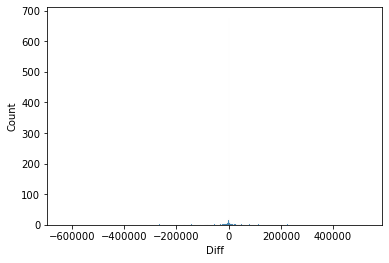

In [55]:
plt.figure()
sns.histplot(selected_data['Diff'])

In [56]:
# Traitement des différences positives
# Correspond à une PropertyGFATotal plus grande que la somme des différents usetypeGFA

<AxesSubplot:xlabel='Diff', ylabel='Count'>

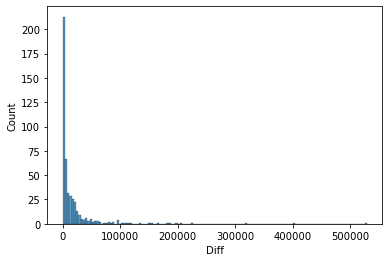

In [57]:
plt.figure()
sns.histplot(selected_data.loc[selected_data['Diff'] > 0, 'Diff'])

In [58]:
selected_data.loc[selected_data['Diff'] > 0, GFA_list]

,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA
2,956110,196718,759392,Hotel,756493.0,NaN,NaN,NaN,NaN
5,97288,37198,60090,Police Station,88830.0,NaN,NaN,NaN,NaN
6,83008,0,83008,Hotel,81352.0,NaN,NaN,NaN,NaN
10,153163,19279,133884,Hotel,133884.0,NaN,NaN,NaN,NaN
18,57452,0,57452,Social/Meeting Hall,16442.0,Restaurant,15505.0,Office,9741.0
...,...,...,...,...,...,...,...,...,...
3360,20616,0,20616,Other - Recreation,9900.0,Fitness Center/Health Club/Gym,8577.0,Pre-school/Daycare,1364.0
3364,16795,0,16795,Other - Recreation,8680.0,Fitness Center/Health Club/Gym,7014.0,Pre-school/Daycare,535.0
3368,20050,0,20050,Other - Recreation,8108.0,Fitness Center/Health Club/Gym,7726.0,Office,3779.0
3374,14101,0,14101,Other - Recreation,6601.0,Fitness Center/Health Club/Gym,6501.0,Pre-school/Daycare,484.0


472 bâtiments
- La différence peut être positive s'il y a plus de 3 usetype (et donc tous les usetypeGFA ne sont pas comptés)

In [59]:
selected_data.loc[(selected_data['Diff'] > 0) & (~selected_data['ThirdLargestPropertyUseTypeGFA'].isna()), GFA_list]

,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA
18,57452,0,57452,Social/Meeting Hall,16442.0,Restaurant,15505.0,Office,9741.0
32,87262,0,87262,Office,40943.0,K-12 School,18153.0,Other - Entertainment/Public Assembly,4307.0
42,70586,0,70586,Self-Storage Facility,38439.0,Vocational School,28197.0,Office,3859.0
47,52549,0,52549,Other - Entertainment/Public Assembly,23500.0,Restaurant,23500.0,Office,5459.0
50,71150,0,71150,Hotel,41340.0,Parking,13730.0,Retail Store,9604.0
...,...,...,...,...,...,...,...,...,...
3360,20616,0,20616,Other - Recreation,9900.0,Fitness Center/Health Club/Gym,8577.0,Pre-school/Daycare,1364.0
3364,16795,0,16795,Other - Recreation,8680.0,Fitness Center/Health Club/Gym,7014.0,Pre-school/Daycare,535.0
3368,20050,0,20050,Other - Recreation,8108.0,Fitness Center/Health Club/Gym,7726.0,Office,3779.0
3374,14101,0,14101,Other - Recreation,6601.0,Fitness Center/Health Club/Gym,6501.0,Pre-school/Daycare,484.0


In [60]:
# 161 bâtiments ont plus de 3 use type
selected_data.loc[(selected_data['Diff'] > 0) & (selected_data['ThirdLargestPropertyUseTypeGFA'].isna()), GFA_list]

,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA
2,956110,196718,759392,Hotel,756493.0,NaN,NaN,NaN,NaN
5,97288,37198,60090,Police Station,88830.0,NaN,NaN,NaN,NaN
6,83008,0,83008,Hotel,81352.0,NaN,NaN,NaN,NaN
10,153163,19279,133884,Hotel,133884.0,NaN,NaN,NaN,NaN
20,540360,0,540360,Courthouse,537150.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
3240,56988,0,56988,Automobile Dealership,24520.0,NaN,NaN,NaN,NaN
3270,20993,0,20993,"Repair Services (Vehicle, Shoe, Locksmith, etc)",20983.0,NaN,NaN,NaN,NaN
3290,101580,14004,87576,Self-Storage Facility,87576.0,NaN,NaN,NaN,NaN
3320,480702,163260,317442,Office,341897.0,Parking,136594.0,NaN,NaN


In [61]:
# Utiliser un masque pour identifier les bâtiments pour lesquels le parking n'a pas été rajouté en propertyusetype
# différence positive + surface de parking positive + pas de parking en property use type (largest et secondlargest) + pas de third largest property use type
df_parking_to_add = (selected_data['Diff'] > 0) & (selected_data['PropertyGFAParking'] > 0) & (selected_data['LargestPropertyUseType'] != 'Parking') & (selected_data['SecondLargestPropertyUseType'] != 'Parking') & (selected_data['ThirdLargestPropertyUseType'].isna())

In [62]:
selected_data[df_parking_to_add]

,OSEBuildingID,PrimaryPropertyType,PropertyName,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,...,SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kBtu),NaturalGas(kBtu),TotalGHGEmissions,GHGEmissionsIntensity,SumGFA,Sum_UT_GFA,Diff
2,3,Hotel,5673-The Westin Seattle,7,DOWNTOWN,47.613930,-122.33810,1969,1.0,41,...,7.258702e+07,7.393711e+07,2.156655e+07,49526664.0,1493800.0,2089.28,2.19,956110,756493.0,199617.0
5,9,Other,West Precinct,7,DOWNTOWN,47.616230,-122.33657,1999,1.0,2,...,1.208662e+07,1.258171e+07,0.000000e+00,7371434.0,4715182.0,301.81,3.10,97288,88830.0,8458.0
10,15,Hotel,Hotel Monaco Seattle,7,DOWNTOWN,47.606950,-122.33414,1969,1.0,11,...,1.601664e+07,1.664693e+07,5.237166e+06,6187627.0,4591850.0,691.26,4.51,153163,133884.0,19279.0
27,33,Hotel,Marriott Springhill Suites (33),7,DOWNTOWN,47.617840,-122.32966,2001,1.0,10,...,1.106192e+07,1.117141e+07,0.000000e+00,5610706.0,5451210.0,328.63,1.91,171866,128909.0,42957.0
29,35,Hotel,Hotel Five,7,DOWNTOWN,47.615580,-122.34186,1978,1.0,5,...,4.456714e+06,4.557974e+06,0.000000e+00,2346349.0,2110365.0,128.44,1.88,68410,47994.0,20416.0
53,68,Hotel,Rainier Hospitality,7,LAKE UNION,47.620010,-122.34274,2000,1.0,7,...,6.715187e+06,6.835264e+06,0.000000e+00,3396109.0,3319078.0,199.95,1.33,150453,110547.0,39906.0
101,167,Other,Wing Luke Museum,2,DOWNTOWN,47.598090,-122.32283,1910,1.0,4,...,2.010455e+06,2.095175e+06,0.000000e+00,1311669.0,698785.0,46.26,0.64,72820,58000.0,14820.0
115,183,Residence Hall,Emerson Hall,7,MAGNOLIA / QUEEN ANNE,47.650680,-122.36331,2001,1.0,4,...,4.448582e+06,4.800620e+06,0.000000e+00,2316298.0,2132284.0,129.39,0.93,139600,135520.0,4080.0
119,338,Other,Jack R. McDonald Building,7,DOWNTOWN,47.615980,-122.33448,2004,1.0,11,...,6.533698e+07,6.600030e+07,0.000000e+00,30651644.0,34685331.0,2055.82,6.87,299070,250000.0,49070.0
147,235,Hotel,311jk-Seattle Downtown/Lake Union CY,7,MAGNOLIA / QUEEN ANNE,47.627820,-122.34045,1998,1.0,7,...,1.117199e+07,1.175409e+07,0.000000e+00,5530787.0,5641200.0,338.16,1.63,207656,141591.0,66065.0


In [63]:
# 53 bâtiments à implémenter
selected_data.loc[df_parking_to_add, 'ThirdLargestPropertyUseTypeGFA'] = selected_data[df_parking_to_add]['PropertyGFAParking']
selected_data.loc[df_parking_to_add, 'ThirdLargestPropertyUseType'] = 'Parking'

In [64]:
selected_data.loc[df_parking_to_add, GFA_list]

,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA
2,956110,196718,759392,Hotel,756493.0,NaN,NaN,Parking,196718.0
5,97288,37198,60090,Police Station,88830.0,NaN,NaN,Parking,37198.0
10,153163,19279,133884,Hotel,133884.0,NaN,NaN,Parking,19279.0
27,171866,38281,133585,Hotel,128909.0,NaN,NaN,Parking,38281.0
29,68410,16200,52210,Hotel,47994.0,NaN,NaN,Parking,16200.0
53,150453,34735,115718,Hotel,107547.0,Restaurant,3000.0,Parking,34735.0
101,72820,13820,59000,Museum,58000.0,NaN,NaN,Parking,13820.0
115,139600,37500,102100,Residence Hall/Dormitory,135520.0,NaN,NaN,Parking,37500.0
119,299070,68432,230638,Other,250000.0,NaN,NaN,Parking,68432.0
147,207656,54341,153315,Hotel,141591.0,NaN,NaN,Parking,54341.0


In [65]:
#Recalculer la somme des GFA usetype, puis la diff avec le total
selected_data['Sum_UT_GFA'] = selected_data['LargestPropertyUseTypeGFA'].fillna(0) + selected_data['SecondLargestPropertyUseTypeGFA'].fillna(0) + selected_data['ThirdLargestPropertyUseTypeGFA'].fillna(0)
selected_data['Diff'] = selected_data['SumGFA'] - selected_data['Sum_UT_GFA']

<AxesSubplot:xlabel='Diff', ylabel='Count'>

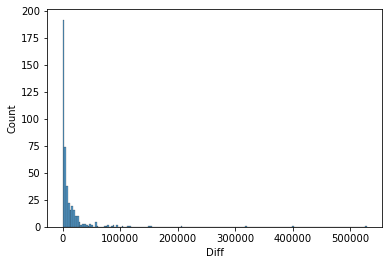

In [66]:
plt.figure()
sns.histplot(selected_data.loc[selected_data['Diff'] > 0, 'Diff'])

In [67]:
selected_data['Diff'].value_counts()

 0.0        635
 1.0          3
-1.0          3
 1000.0       2
-1003.0       2
           ... 
 61959.0      1
 200.0        1
 8146.0       1
 7236.0       1
 879.0        1
Name: Diff, Length: 805, dtype: int64

<AxesSubplot:xlabel='Diff', ylabel='Count'>

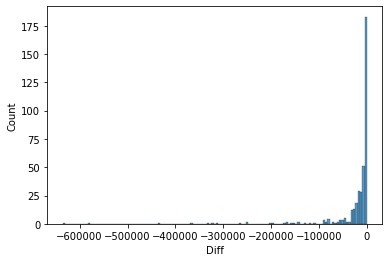

In [68]:
#Visualisation des différences négatives
plt.figure()
sns.histplot(selected_data.loc[selected_data['Diff'] < 0, 'Diff'])

In [69]:
# Lorsque la différence est négative = incohérent et impossible de savoir si le total est sous-estimé ou si un usetypeGFA est surestimé
selected_data.loc[selected_data['Diff'] < 0, GFA_list]

,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA
4,175580,62000,113580,Hotel,123445.0,Parking,68009.0,NaN,NaN
5,97288,37198,60090,Police Station,88830.0,NaN,NaN,Parking,37198.000000
11,333176,61161,272015,Hotel,336640.0,NaN,NaN,NaN,NaN
13,315952,57600,258352,Hotel,295511.0,Parking,57600.0,NaN,NaN
14,92190,25200,66990,Hotel,67390.0,Parking,25200.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...
3324,483397,166208,317189,Office,342173.0,Parking,147597.0,NaN,NaN
3329,536697,197659,339038,Office,342838.0,Parking,202178.0,Retail Store,6313.200195
3337,126823,41539,85284,Hotel,88157.0,Parking,41539.0,NaN,NaN
3347,45000,0,45000,K-12 School,45728.0,NaN,NaN,NaN,NaN


Trop de bâtiments (385) concernés et certaines différences sont petites donc suppression uniquement des bâtiments pour lesquels le ratio différence/GFAtotal est supérieur à 30%.

Pour l'encodage utiliser selected_data['Sum_UT_GFA'] comme total pour la proportion de chaque type.

In [70]:
# Calculer le ratio diff/GFA total
selected_data['Ratio'] = selected_data['Diff'] / selected_data['SumGFA']

In [71]:
selected_data['Ratio'].sort_values()

3165   -5.426849
2246   -2.997791
3294   -2.643604
619    -2.437652
3132   -1.904108
          ...   
2833    0.600971
638     0.611712
2019    0.677023
34      0.762360
3267    0.781980
Name: Ratio, Length: 1460, dtype: float64

<AxesSubplot:xlabel='Ratio', ylabel='Count'>

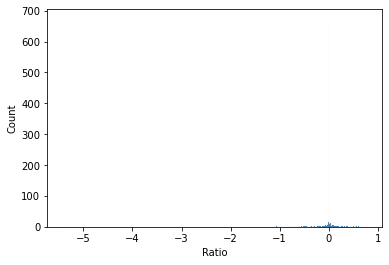

In [72]:
plt.figure()
sns.histplot(selected_data['Ratio'])

In [73]:
selected_data.loc[selected_data['Ratio']>0.3]

,OSEBuildingID,PrimaryPropertyType,PropertyName,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,...,SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kBtu),NaturalGas(kBtu),TotalGHGEmissions,GHGEmissionsIntensity,SumGFA,Sum_UT_GFA,Diff,Ratio
34,41,Self-Storage Facility,08781-University Village,4,NORTHEAST,47.66172,-122.29598,1955,1.0,2,...,3.262231e+05,0.00,281265.0,37100.0,3.93,0.04,110356,26225.0,84131.0,0.762360
46,59,Small- and Mid-Sized Office,Gibraltar Tower,7,DOWNTOWN,47.61048,-122.33794,1910,1.0,8,...,5.242480e+06,0.00,5071973.0,0.0,35.36,0.60,59400,39940.0,19460.0,0.327609
90,132,Other,Roosevelt Square,4,NORTHEAST,47.67559,-122.31769,1929,1.0,2,...,4.384626e+06,0.00,2001103.0,2252474.0,133.58,0.65,206934,119146.0,87788.0,0.424232
97,145,Other,Benaroya Hall,7,DOWNTOWN,47.60804,-122.33670,1998,1.0,6,...,1.488195e+07,4311136.00,9803021.0,527343.0,429.12,1.51,284100,189750.0,94350.0,0.332101
224,348,Large Office,1101 Second Avenue (HOB),7,DOWNTOWN,47.60581,-122.33664,1968,1.0,8,...,3.743228e+06,0.00,3743228.0,0.0,26.10,0.17,157941,100239.0,57702.0,0.365339
372,524,Large Office,Plaza 701 N 34th,6,LAKE UNION,47.64882,-122.34905,1999,1.0,4,...,8.651835e+06,0.00,8116657.0,535178.0,85.01,0.35,243334,163544.0,79790.0,0.327903
403,561,Large Office,Alley24,7,LAKE UNION,47.62029,-122.33078,2005,1.0,6,...,9.200102e+06,0.00,7877393.0,0.0,54.92,0.16,336700,222546.0,114154.0,0.339038
413,572,Mixed Use Property,Bright Horizons,7,LAKE UNION,47.62405,-122.33084,1928,1.0,1,...,2.758082e+06,0.00,1612547.0,991384.0,63.89,0.98,65000,45000.0,20000.0,0.307692
497,678,Large Office,Colman Building,7,DOWNTOWN,47.60353,-122.33558,1900,1.0,6,...,8.455976e+06,2068666.75,4325997.0,1743952.0,282.46,1.37,205521,143562.0,61959.0,0.301473
515,702,Small- and Mid-Sized Office,Hays Elliot,7,MAGNOLIA / QUEEN ANNE,47.63156,-122.37551,1937,1.0,2,...,2.421613e+06,0.00,1328054.0,874972.0,55.73,0.90,61929,39879.0,22050.0,0.356053


In [74]:
selected_data.loc[selected_data['Ratio']<-0.3]

,OSEBuildingID,PrimaryPropertyType,PropertyName,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,...,SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kBtu),NaturalGas(kBtu),TotalGHGEmissions,GHGEmissionsIntensity,SumGFA,Sum_UT_GFA,Diff,Ratio
36,46,Warehouse,Seattle 11-13,2,GREATER DUWAMISH,47.51138,-122.28875,1961,3.0,2,...,4.411002e+07,0.0,44731153.0,0.0,311.84,0.44,714095,963000.0,-248905.0,-0.348560
59,84,Senior Care Community,PSSA - The Mount,1,SOUTHWEST,47.55837,-122.37751,1922,1.0,5,...,4.554725e+07,0.0,11824772.0,30967300.0,1727.11,7.94,217603,296313.0,-78710.0,-0.361714
67,100,Large Office,City Place III - SEDO,7,LAKE UNION,47.62424,-122.33646,2010,1.0,5,...,1.390927e+07,0.0,12871091.0,924861.0,138.85,0.44,316306,427691.0,-111385.0,-0.352143
72,107,Large Office,City Place IV - SEDO,7,LAKE UNION,47.62112,-122.33629,2010,1.0,12,...,4.015343e+07,0.0,32206199.0,7399685.0,617.52,1.08,571329,935703.0,-364374.0,-0.637766
74,111,Other,Mercer Arena,7,MAGNOLIA / QUEEN ANNE,47.62395,-122.35077,1928,1.0,1,...,8.759433e+05,0.0,875943.0,0.0,6.11,0.10,60696,108000.0,-47304.0,-0.779359
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3253,49911,Other,Educare Early Learning Center,1,DELRIDGE,47.51377,-122.34328,2010,1.0,2,...,1.679541e+06,0.0,953635.0,592850.0,38.13,0.86,44162,59923.0,-15761.0,-0.356891
3264,49940,Hospital,Virginia Mason Medical Center - 2149,3,EAST,47.60986,-122.32774,1920,1.0,8,...,1.672071e+08,73885472.0,90060497.0,0.0,6330.91,16.91,374466,1010135.0,-635669.0,-1.697535
3281,49985,Large Office,Amazon Phase VI,7,LAKE UNION,47.62384,-122.33941,2014,1.0,6,...,1.681085e+07,0.0,14213039.0,2157998.0,213.70,0.50,427181,596376.0,-169195.0,-0.396073
3294,50002,Other,Audi Seattle UVA Bldg,4,NORTHEAST,47.66414,-122.31664,2014,1.0,3,...,1.399582e+06,0.0,1399582.0,0.0,9.76,0.29,33648,122600.0,-88952.0,-2.643604


In [75]:
# Supprimer les bâtiments pour lesquels ratio > 0.3 ou <-0.3
selected_data = selected_data.drop(selected_data.loc[selected_data['Ratio']>0.3].index)
selected_data = selected_data.drop(selected_data.loc[selected_data['Ratio']<-0.3].index)

In [76]:
selected_data

,OSEBuildingID,PrimaryPropertyType,PropertyName,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,...,SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kBtu),NaturalGas(kBtu),TotalGHGEmissions,GHGEmissionsIntensity,SumGFA,Sum_UT_GFA,Diff,Ratio
0,1,Hotel,Mayflower park hotel,7,DOWNTOWN,47.61220,-122.33799,1927,1.0,12,...,7.456910e+06,2003882.00,3.946027e+06,1.276453e+06,249.98,2.83,88434,88434.0,0.0,0.000000
1,2,Hotel,Paramount Hotel,7,DOWNTOWN,47.61317,-122.33393,1996,1.0,11,...,8.664479e+06,0.00,3.242851e+06,5.145082e+06,295.86,2.86,103566,103566.0,0.0,0.000000
2,3,Hotel,5673-The Westin Seattle,7,DOWNTOWN,47.61393,-122.33810,1969,1.0,41,...,7.393711e+07,21566554.00,4.952666e+07,1.493800e+06,2089.28,2.19,956110,953211.0,2899.0,0.003032
3,5,Hotel,HOTEL MAX,7,DOWNTOWN,47.61412,-122.33664,1926,1.0,10,...,6.946800e+06,2214446.25,2.768924e+06,1.811213e+06,286.43,4.67,61320,61320.0,0.0,0.000000
4,8,Hotel,WARWICK SEATTLE HOTEL (ID8),7,DOWNTOWN,47.61375,-122.34047,1980,1.0,18,...,1.465650e+07,0.00,5.368607e+06,8.803998e+06,505.01,2.88,175580,191454.0,-15874.0,-0.090409
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3370,50221,Other,High Point Community Center,1,DELRIDGE,47.54067,-122.37441,1982,1.0,1,...,1.025432e+06,0.00,6.323620e+05,2.997200e+05,20.33,1.11,18261,18261.0,0.0,0.000000
3372,50223,Other,International district/Chinatown CC,2,DOWNTOWN,47.59625,-122.32283,2004,1.0,1,...,1.053706e+06,0.00,3.965461e+05,5.537300e+05,32.17,2.01,16000,16000.0,0.0,0.000000
3373,50224,Other,Queen Anne Pool,7,MAGNOLIA / QUEEN ANNE,47.63644,-122.35784,1974,1.0,1,...,6.053764e+06,0.00,1.792159e+06,3.973739e+06,223.54,16.99,13157,13157.0,0.0,0.000000
3374,50225,Mixed Use Property,South Park Community Center,1,GREATER DUWAMISH,47.52832,-122.32431,1989,1.0,1,...,7.828413e+05,0.00,3.488702e+05,3.706010e+05,22.11,1.57,14101,13586.0,515.0,0.036522


### Encodage des données de propertyusetype

In [77]:
# Encoder les données de use type pour que chaque UT soit une variable avec les proportions en valeur
# Travailler sur un df à part
use_type = ['OSEBuildingID', 'PropertyGFATotal', 'LargestPropertyUseType', 'LargestPropertyUseTypeGFA', 'SecondLargestPropertyUseType', 'SecondLargestPropertyUseTypeGFA', 'ThirdLargestPropertyUseType', 'ThirdLargestPropertyUseTypeGFA', 'Sum_UT_GFA']
df_use_type = selected_data[use_type]

In [78]:
# Calculer les proportions de chaque UT (par rapport à la somme des UT et non au GFA total)
df_use_type.loc[:, 'ProportionPUT1'] = df_use_type['LargestPropertyUseTypeGFA'] / df_use_type['Sum_UT_GFA']
df_use_type.loc[:, 'ProportionPUT2'] = df_use_type['SecondLargestPropertyUseTypeGFA'] / df_use_type['Sum_UT_GFA']
df_use_type.loc[:, 'ProportionPUT3'] = df_use_type['ThirdLargestPropertyUseTypeGFA'] / df_use_type['Sum_UT_GFA']

D:\Users\Aline\anaconda3\lib\site-packages\pandas\core\indexing.py:1667: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.obj[key] = value


In [79]:
df_use_type.isna().sum()

OSEBuildingID                         0
PropertyGFATotal                      0
LargestPropertyUseType                0
LargestPropertyUseTypeGFA             0
SecondLargestPropertyUseType        691
SecondLargestPropertyUseTypeGFA     691
ThirdLargestPropertyUseType        1027
ThirdLargestPropertyUseTypeGFA     1027
Sum_UT_GFA                            0
ProportionPUT1                        0
ProportionPUT2                      691
ProportionPUT3                     1027
dtype: int64

In [80]:
# Remplacer les NaN par 0
df_use_type.loc[:, 'ProportionPUT2'].fillna(0, inplace=True)
df_use_type.loc[:, 'ProportionPUT3'].fillna(0, inplace=True)

D:\Users\Aline\anaconda3\lib\site-packages\pandas\core\generic.py:6392: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return self._update_inplace(result)


In [81]:
df_use_type

,OSEBuildingID,PropertyGFATotal,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,Sum_UT_GFA,ProportionPUT1,ProportionPUT2,ProportionPUT3
0,1,88434,Hotel,88434.0,NaN,NaN,NaN,NaN,88434.0,1.000000,0.000000,0.000000
1,2,103566,Hotel,83880.0,Parking,15064.0,Restaurant,4622.0,103566.0,0.809918,0.145453,0.044629
2,3,956110,Hotel,756493.0,NaN,NaN,Parking,196718.0,953211.0,0.793626,0.000000,0.206374
3,5,61320,Hotel,61320.0,NaN,NaN,NaN,NaN,61320.0,1.000000,0.000000,0.000000
4,8,175580,Hotel,123445.0,Parking,68009.0,NaN,NaN,191454.0,0.644776,0.355224,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
3370,50221,18261,Other - Recreation,18261.0,NaN,NaN,NaN,NaN,18261.0,1.000000,0.000000,0.000000
3372,50223,16000,Other - Recreation,16000.0,NaN,NaN,NaN,NaN,16000.0,1.000000,0.000000,0.000000
3373,50224,13157,Other - Recreation,7583.0,Fitness Center/Health Club/Gym,5574.0,NaN,NaN,13157.0,0.576347,0.423653,0.000000
3374,50225,14101,Other - Recreation,6601.0,Fitness Center/Health Club/Gym,6501.0,Pre-school/Daycare,484.0,13586.0,0.485868,0.478507,0.035625


In [82]:
# Encodage des données
encoded_type1 = pd.pivot_table(df_use_type, values='ProportionPUT1', dropna=False, index='OSEBuildingID', columns=['LargestPropertyUseType'], aggfunc=np.sum, fill_value=np.nan)
encoded_type2 = pd.pivot_table(df_use_type, values='ProportionPUT2', dropna=False, index='OSEBuildingID', columns=['SecondLargestPropertyUseType'], aggfunc=np.sum, fill_value=np.nan)
encoded_type3 = pd.pivot_table(df_use_type, values='ProportionPUT3', dropna=False, index='OSEBuildingID', columns=['ThirdLargestPropertyUseType'], aggfunc=np.sum, fill_value=np.nan)

In [83]:
encoded_type = encoded_type1.fillna(encoded_type2)

In [84]:
encoded_type = encoded_type.fillna(encoded_type3)

In [85]:
# Vérification
encoded_type.sum(axis=1, skipna=True)

OSEBuildingID
1        1.0
2        1.0
3        1.0
5        1.0
8        1.0
        ... 
50221    1.0
50223    1.0
50224    1.0
50225    1.0
50226    1.0
Length: 1347, dtype: float64

In [86]:
# Vérification de quelques valeurs
encoded_type.loc[50225, ['Other - Recreation', 'Fitness Center/Health Club/Gym', 'Pre-school/Daycare']]

LargestPropertyUseType
Other - Recreation                0.485868
Fitness Center/Health Club/Gym    0.478507
Pre-school/Daycare                0.035625
Name: 50225, dtype: float64

In [87]:
encoded_type.loc[2, ['Hotel', 'Parking', 'Restaurant']]

LargestPropertyUseType
Hotel         0.809918
Parking       0.145453
Restaurant    0.044629
Name: 2, dtype: float64

In [88]:
encoded_type.loc[8, ['Hotel', 'Parking', 'Restaurant']]

LargestPropertyUseType
Hotel         0.644776
Parking       0.355224
Restaurant         NaN
Name: 8, dtype: float64

In [89]:
df_use_type

,OSEBuildingID,PropertyGFATotal,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,Sum_UT_GFA,ProportionPUT1,ProportionPUT2,ProportionPUT3
0,1,88434,Hotel,88434.0,NaN,NaN,NaN,NaN,88434.0,1.000000,0.000000,0.000000
1,2,103566,Hotel,83880.0,Parking,15064.0,Restaurant,4622.0,103566.0,0.809918,0.145453,0.044629
2,3,956110,Hotel,756493.0,NaN,NaN,Parking,196718.0,953211.0,0.793626,0.000000,0.206374
3,5,61320,Hotel,61320.0,NaN,NaN,NaN,NaN,61320.0,1.000000,0.000000,0.000000
4,8,175580,Hotel,123445.0,Parking,68009.0,NaN,NaN,191454.0,0.644776,0.355224,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
3370,50221,18261,Other - Recreation,18261.0,NaN,NaN,NaN,NaN,18261.0,1.000000,0.000000,0.000000
3372,50223,16000,Other - Recreation,16000.0,NaN,NaN,NaN,NaN,16000.0,1.000000,0.000000,0.000000
3373,50224,13157,Other - Recreation,7583.0,Fitness Center/Health Club/Gym,5574.0,NaN,NaN,13157.0,0.576347,0.423653,0.000000
3374,50225,14101,Other - Recreation,6601.0,Fitness Center/Health Club/Gym,6501.0,Pre-school/Daycare,484.0,13586.0,0.485868,0.478507,0.035625


In [90]:
encoded_type.describe()

LargestPropertyUseType,Adult Education,Automobile Dealership,Bank Branch,College/University,Courthouse,Data Center,Distribution Center,Financial Office,Fire Station,Fitness Center/Health Club/Gym,...,Residential Care Facility,Restaurant,Retail Store,Self-Storage Facility,Senior Care Community,Social/Meeting Hall,Strip Mall,Supermarket/Grocery Store,Urgent Care/Clinic/Other Outpatient,Worship Facility
count,3.000000,4.000000,13.000000,19.000000,2.000000,27.000000,60.000000,8.000000,1.0,20.000000,...,1.0,64.000000,187.000000,31.000000,17.000000,13.000000,6.000000,44.000000,4.0,65.000000
mean,0.465832,0.981907,0.296997,0.931441,0.681447,0.141472,0.799242,0.465876,1.0,0.357092,...,1.0,0.236598,0.485461,0.848463,0.917721,0.548486,0.757384,0.792558,1.0,0.940635
std,0.464172,0.036187,0.303128,0.222402,0.450501,0.241601,0.247718,0.422812,NaN,0.229751,...,NaN,0.298872,0.371252,0.294606,0.152736,0.386128,0.383106,0.312428,0.0,0.152296
min,0.160609,0.927627,0.021179,0.079164,0.362895,0.001109,0.119439,0.022423,1.0,0.040233,...,1.0,0.002124,0.011451,0.035138,0.560544,0.029521,0.154894,0.035876,1.0,0.196937
25%,0.198749,0.981907,0.099150,1.000000,0.522171,0.004890,0.663655,0.090879,1.0,0.222424,...,1.0,0.044432,0.151462,0.901763,0.919359,0.256062,0.542056,0.511775,1.0,1.000000
50%,0.236889,1.000000,0.200272,1.000000,0.681447,0.029531,0.896205,0.368808,1.0,0.379291,...,1.0,0.111142,0.399361,1.000000,1.000000,0.521417,1.000000,1.000000,1.0,1.000000
75%,0.618444,1.000000,0.289552,1.000000,0.840724,0.164298,1.000000,0.849796,1.0,0.439296,...,1.0,0.265534,0.983355,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000,...,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000


In [91]:
encoded_type

LargestPropertyUseType,Adult Education,Automobile Dealership,Bank Branch,College/University,Courthouse,Data Center,Distribution Center,Financial Office,Fire Station,Fitness Center/Health Club/Gym,...,Residential Care Facility,Restaurant,Retail Store,Self-Storage Facility,Senior Care Community,Social/Meeting Hall,Strip Mall,Supermarket/Grocery Store,Urgent Care/Clinic/Other Outpatient,Worship Facility
OSEBuildingID,,,,,,,,,,,,,,,,,,,,,
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.044629,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50221,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50223,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50224,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.423653,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [92]:
encoded_type.fillna(0, inplace=True)

### Analyse des données d'énergie

In [93]:
energy_list = ['ENERGYSTARScore', 'SiteEUIWN(kBtu/sf)', 'SourceEUIWN(kBtu/sf)', 'SiteEnergyUse(kBtu)', 'SiteEnergyUseWN(kBtu)', 'SteamUse(kBtu)', 'Electricity(kBtu)', 'NaturalGas(kBtu)', 'TotalGHGEmissions', 'GHGEmissionsIntensity']

In [94]:
selected_data[energy_list].describe()

,ENERGYSTARScore,SiteEUIWN(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kBtu),NaturalGas(kBtu),TotalGHGEmissions,GHGEmissionsIntensity
count,888.000000,1347.000000,1347.000000,1.347000e+03,1.347000e+03,1.347000e+03,1.347000e+03,1.347000e+03,1347.000000,1347.000000
mean,63.372748,76.006385,182.857461,7.214653e+06,7.317314e+06,3.696789e+05,5.224164e+06,1.569292e+06,148.299599,1.546117
std,28.784266,75.340690,190.637603,1.693783e+07,1.708847e+07,4.064265e+06,1.249351e+07,5.267612e+06,483.362879,2.034323
min,1.000000,0.000000,-2.100000,5.713320e+04,0.000000e+00,0.000000e+00,-1.154170e+05,0.000000e+00,-0.800000,-0.020000
25%,44.000000,36.599998,81.750000,1.165068e+06,1.248998e+06,0.000000e+00,6.853410e+05,0.000000e+00,19.650000,0.345000
50%,70.000000,55.799999,140.699997,2.586116e+06,2.699616e+06,0.000000e+00,1.597279e+06,4.229940e+05,47.390000,0.850000
75%,88.000000,86.549999,209.649994,6.851194e+06,7.047674e+06,0.000000e+00,4.866961e+06,1.382430e+06,134.090000,1.935000
max,100.000000,834.400024,2620.000000,2.916144e+08,2.959299e+08,1.349435e+08,2.745325e+08,1.381912e+08,12307.160000,16.990000


In [95]:
def histogramme(variable):
    plt.figure()
    plt.xticks(rotation=30, ha='right')
    sns.histplot(data=selected_data[variable])

In [96]:
def boxplot(variable):
    plt.figure()
    plt.title(variable)
    sns.boxplot(data=selected_data[variable])

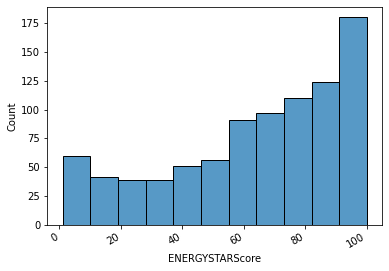

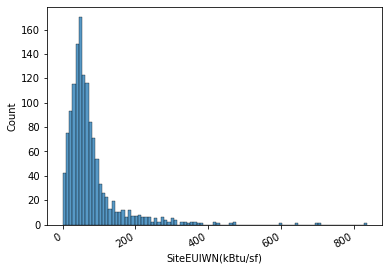

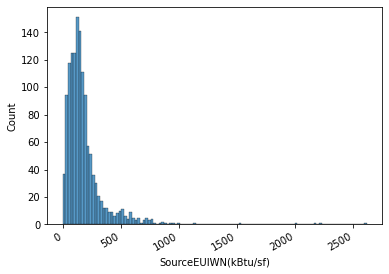

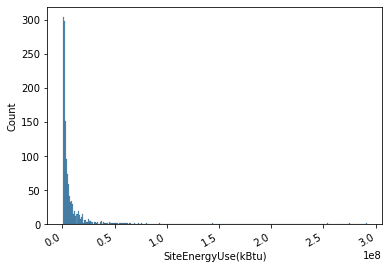

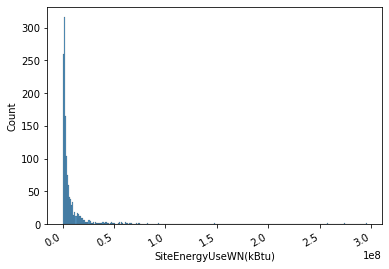

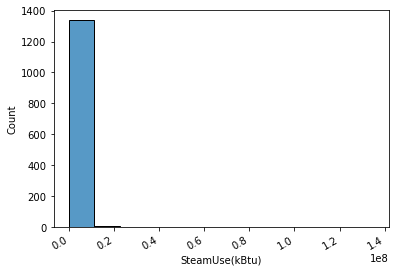

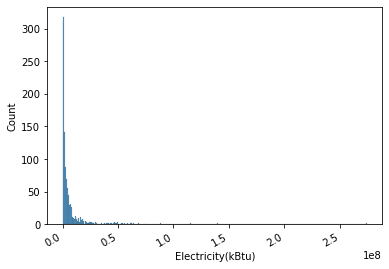

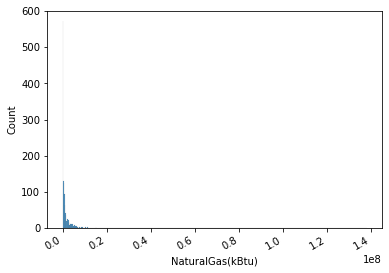

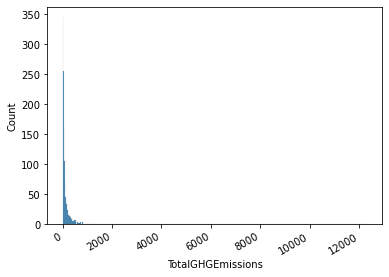

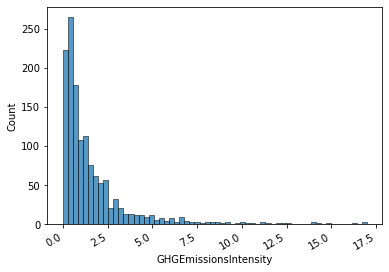

In [97]:
for i in energy_list:
    histogramme(i)

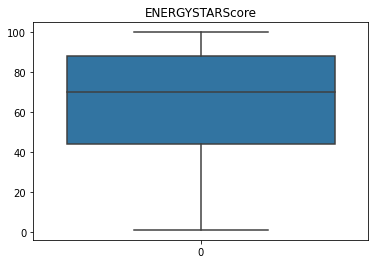

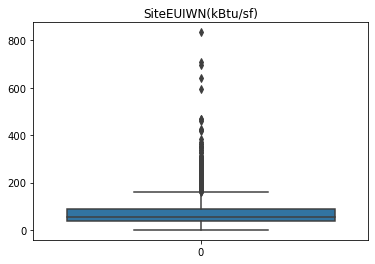

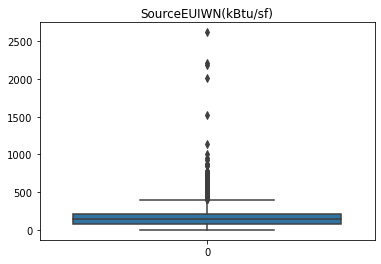

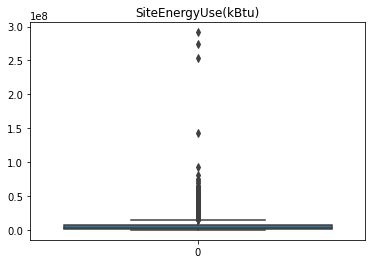

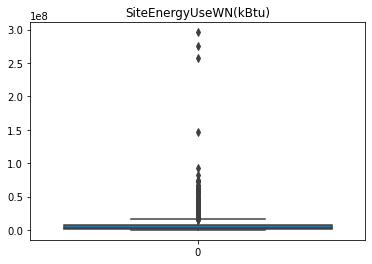

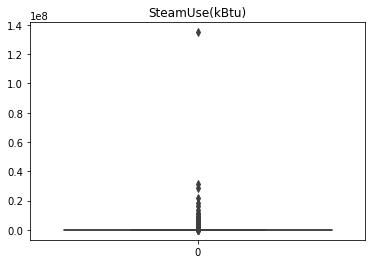

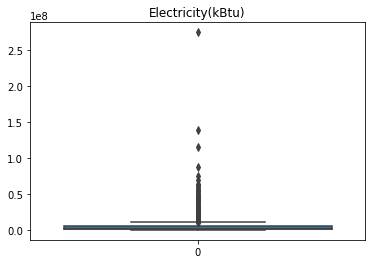

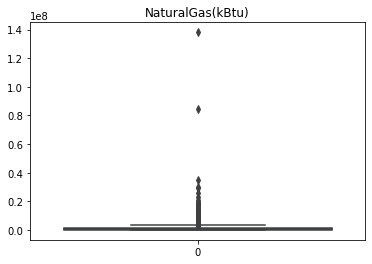

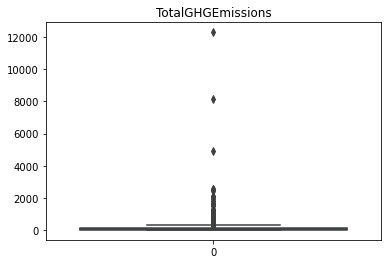

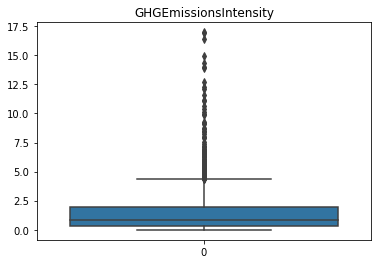

In [98]:
for i in energy_list:
    boxplot(i)

In [99]:
# Vérifier les outliers en regroupant par catégorie propertytype

In [100]:
def graphiques(variable, cible):
    groupes = []
    
    for cat in selected_data[variable].unique():
        if selected_data[cible].isna().sum() != 0:
            groupes.append(selected_data.loc[selected_data[variable] == cat].dropna()[cible])
        else:
            groupes.append(selected_data.loc[selected_data[variable] == cat][cible])
    
    medianprops = {'color':"black"}
    meanprops = {'marker':'o', 'markeredgecolor':'black',
            'markerfacecolor':'firebrick'}
    plt.boxplot(groupes, labels=selected_data[variable].unique(), showfliers=True, medianprops=medianprops, 
            vert=False, patch_artist=True, showmeans=True, meanprops=meanprops)
    plt.title(cible)
    plt.show()

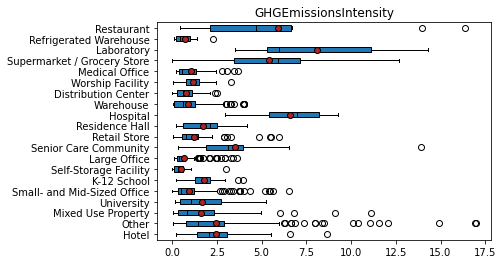

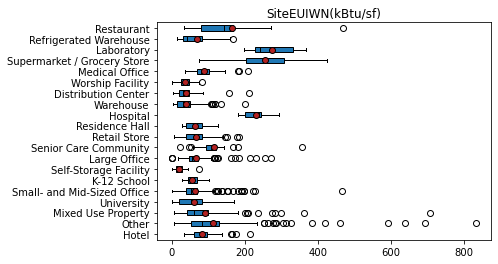

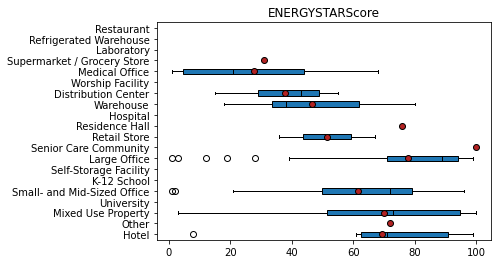

In [101]:
cibles = ['GHGEmissionsIntensity', 'SiteEUIWN(kBtu/sf)', 'ENERGYSTARScore']
for i in cibles:
    graphiques('PrimaryPropertyType', i)

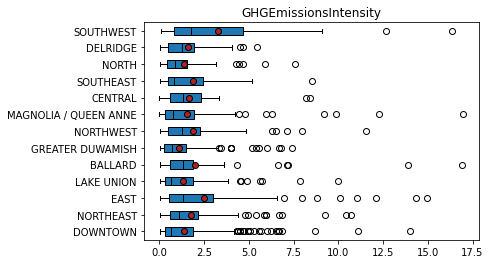

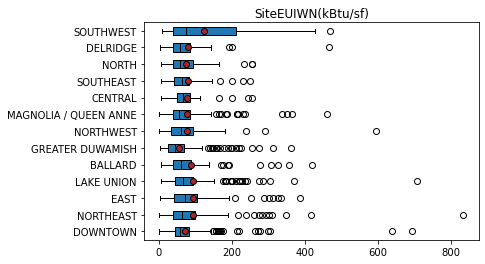

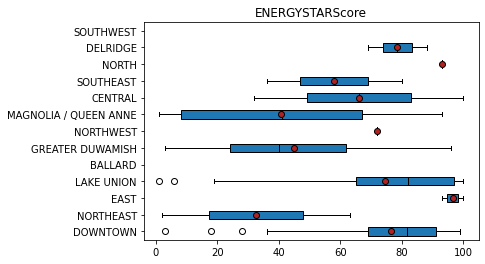

In [102]:
for i in cibles:
    graphiques('Neighborhood', i)

Vérifier les bâtiments 'très outliers' pour leur catégorie
- GHGEmissionsIntensity : Restaurant, Senior Care community, Mixed Use Property, Other > 10
- SiteEUIWN : Restaurant, Senior Care community, Small- and Mid-Sized Office, Mixed Use Property, Other > 300

In [103]:
GHGE_list = ['Restaurant', 'Senior Care community', 'Mixed Use Property', 'Other']
EUIWN_list = ['Restaurant', 'Senior Care community', 'Small- and Mid-Sized Office', 'Mixed Use Property', 'Other']

In [104]:
outlier = selected_data.loc[selected_data['PrimaryPropertyType'].isin(GHGE_list) & (selected_data['GHGEmissionsIntensity'] > 10)].index

In [105]:
outlier = outlier.append(selected_data.loc[selected_data['PrimaryPropertyType'].isin(EUIWN_list) & (selected_data['SiteEUIWN(kBtu/sf)'] > 300)].index)

In [106]:
# Supprimer ces outliers
selected_data = selected_data.drop(outlier)

In [107]:
selected_data.shape

(1328, 34)

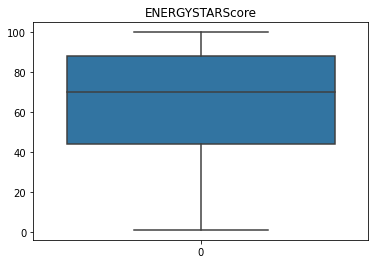

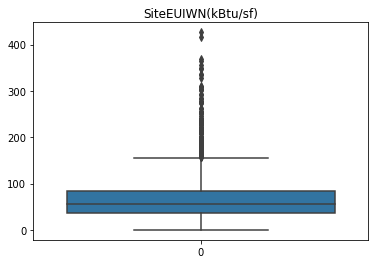

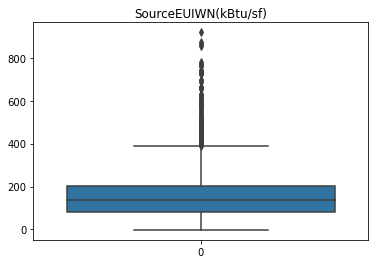

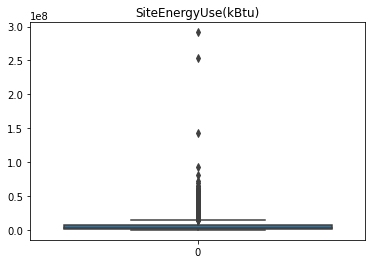

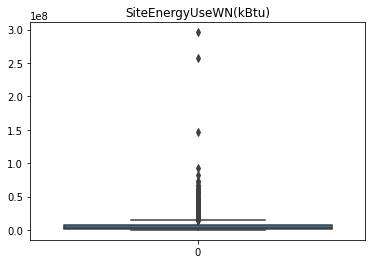

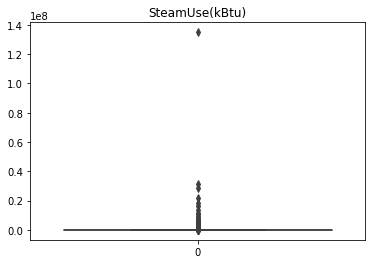

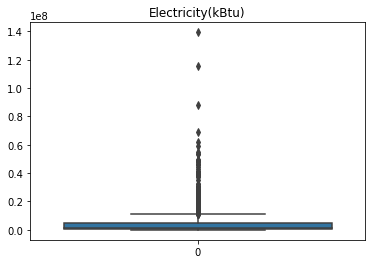

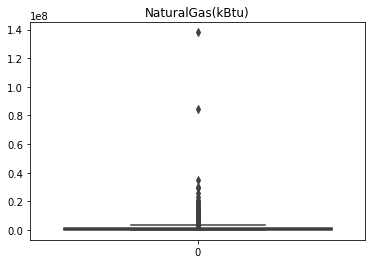

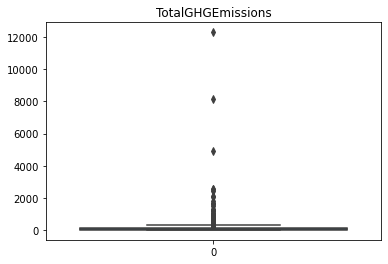

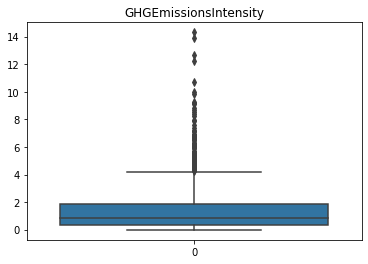

In [108]:
for i in energy_list:
    boxplot(i)

In [109]:
selected_data[energy_list].describe()

,ENERGYSTARScore,SiteEUIWN(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kBtu),NaturalGas(kBtu),TotalGHGEmissions,GHGEmissionsIntensity
count,883.000000,1328.000000,1328.000000,1.328000e+03,1.328000e+03,1.328000e+03,1.328000e+03,1.328000e+03,1328.000000,1328.000000
mean,63.284258,70.791717,170.407756,6.722379e+06,6.824484e+06,3.600930e+05,4.794326e+06,1.529762e+06,142.463667,1.436514
std,28.691526,58.451962,138.171640,1.495564e+07,1.513485e+07,4.081783e+06,9.570670e+06,5.264448e+06,481.778668,1.715958
min,1.000000,0.000000,-2.100000,5.713320e+04,0.000000e+00,0.000000e+00,-1.154170e+05,0.000000e+00,-0.800000,-0.020000
25%,44.000000,36.249999,81.000000,1.159349e+06,1.239286e+06,0.000000e+00,6.808380e+05,0.000000e+00,19.362500,0.340000
50%,70.000000,55.199999,138.349998,2.522356e+06,2.632387e+06,0.000000e+00,1.569072e+06,4.201170e+05,46.565000,0.830000
75%,88.000000,84.375002,204.774998,6.669711e+06,6.784971e+06,0.000000e+00,4.744002e+06,1.370250e+06,129.515000,1.890000
max,100.000000,426.600006,919.299988,2.916144e+08,2.959299e+08,1.349435e+08,1.393548e+08,1.381912e+08,12307.160000,14.320000


- Energy Star Score entre 1 et 100

Site et Source Use
- SiteEUIWN(kBtu/sf) entre 0 et 426.6
- SourceEUIWN(kBtu/sf) entre -2.1 et 919 / valeur négative ?
- SiteEnergyUse(kBtu) entre 57000 et 291 000 000
- SiteEnergyUseWN(kBtu) entre 0 et 295 000 000

Différents types d'énergie
- SteamUse(kBtu) entre 0 et 134 000 000
- Electricity(kBtu) entre -115 000 et 139 000 000 / valeur négative = production d'électricité ?
- NaturalGas(kBtu) entre 0 et 138 000 000

GHGEmission
- TotalGHGEmissions entre -0.8 et 12307
- GHGEmissionsIntensity entre -0.02 et 14.32

In [110]:
# Vérifier les bâtiments avec SiteEUIWN(kBtu/sf) nulle
selected_data.loc[selected_data['SiteEUIWN(kBtu/sf)'] == 0][energy_list]

,ENERGYSTARScore,SiteEUIWN(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kBtu),NaturalGas(kBtu),TotalGHGEmissions,GHGEmissionsIntensity
220,69.0,0.0,0.0,2.490613e+07,0.0,10921066.00,13985064.0,0.0,940.47,2.48
247,65.0,0.0,0.0,2.682322e+07,0.0,0.00,26602310.0,220905.0,197.19,0.40
284,84.0,0.0,0.0,5.446624e+06,0.0,2850077.75,2596546.0,0.0,238.09,1.58
350,75.0,0.0,0.0,3.484916e+06,0.0,0.00,3484915.0,0.0,24.29,0.28
882,88.0,0.0,0.0,4.964773e+05,0.0,0.00,167075.0,329402.0,18.66,0.78
953,52.0,0.0,0.0,1.128179e+06,0.0,0.00,710478.0,417701.0,27.14,0.86
3275,NaN,0.0,0.0,5.000717e+06,0.0,0.00,3719217.0,0.0,25.93,0.44
3277,NaN,0.0,0.0,5.116831e+07,0.0,0.00,28614613.0,0.0,199.48,0.98


In [111]:
# Problème de normalisation météo ? suppression de ces bâtiments
selected_data = selected_data.drop(selected_data.loc[selected_data['SiteEUIWN(kBtu/sf)'] == 0].index)

In [112]:
# Vérifier les bâtiments avec TotalGHGEmissions nulle
selected_data.loc[selected_data['TotalGHGEmissions'] == 0]

,OSEBuildingID,PrimaryPropertyType,PropertyName,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,...,SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kBtu),NaturalGas(kBtu),TotalGHGEmissions,GHGEmissionsIntensity,SumGFA,Sum_UT_GFA,Diff,Ratio
513,700,Supermarket / Grocery Store,IUC- Whole Foods Interbay,7,MAGNOLIA / QUEEN ANNE,47.63718,-122.37734,2008,1.0,1,...,12843856.0,0.0,0.0,0.0,0.0,0.0,57176,60000.0,-2824.0,-0.049391


In [113]:
selected_data = selected_data.drop(selected_data.loc[selected_data['TotalGHGEmissions'] == 0].index)

In [114]:
selected_data.loc[selected_data['SourceEUIWN(kBtu/sf)'] < 0]

,OSEBuildingID,PrimaryPropertyType,PropertyName,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,...,SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kBtu),NaturalGas(kBtu),TotalGHGEmissions,GHGEmissionsIntensity,SumGFA,Sum_UT_GFA,Diff,Ratio
3206,49784,Small- and Mid-Sized Office,Bullitt Center,3,CENTRAL,47.61432,-122.31257,2013,1.0,6,...,240132.0938,0.0,-115417.0,0.0,-0.8,-0.02,52000,48159.0,3841.0,0.073865


In [115]:
# Le Bullitt center est bien un bâtiment à énergie positive mais c'est un cas particulier que l'on peut écarter de notre étude
selected_data = selected_data.drop(selected_data.loc[selected_data['SourceEUIWN(kBtu/sf)'] < 0].index)

In [116]:
# Pour le cleaning vérifier la consistance des données en recalculant les différents site energy use ?
selected_data['EnergyUseSum'] = selected_data['SteamUse(kBtu)'] + selected_data['Electricity(kBtu)'] + selected_data['NaturalGas(kBtu)']

In [117]:
selected_data['DiffEnergyUse'] = selected_data['EnergyUseSum'] - selected_data['SiteEnergyUse(kBtu)']

<AxesSubplot:xlabel='EnergyUseSum', ylabel='SiteEnergyUse(kBtu)'>

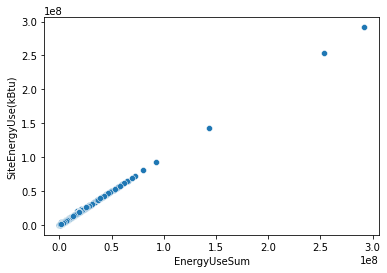

In [118]:
sns.scatterplot(x='EnergyUseSum' , y='SiteEnergyUse(kBtu)', data=selected_data)

In [119]:
selected_data.loc[selected_data['DiffEnergyUse'] > 1, ['EnergyUseSum', 'SiteEnergyUse(kBtu)', 'DiffEnergyUse']]

,EnergyUseSum,SiteEnergyUse(kBtu),DiffEnergyUse
206,41377888.0,40847752.0,530136.0


In [120]:
selected_data = selected_data.drop(selected_data.loc[selected_data['DiffEnergyUse'] > 1].index)

In [121]:
selected_data.loc[selected_data['DiffEnergyUse'] < -100, ['EnergyUseSum', 'SiteEnergyUse(kBtu)', 'DiffEnergyUse']]

,EnergyUseSum,SiteEnergyUse(kBtu),DiffEnergyUse
69,21200976.0,2.365898e+07,-2.458002e+06
70,7874245.0,8.141156e+06,-2.669105e+05
71,17016015.0,2.095503e+07,-3.939011e+06
73,2495729.0,2.726369e+06,-2.306400e+05
75,18649906.0,2.072325e+07,-2.073342e+06
371,11323163.0,1.132551e+07,-2.350000e+03
1105,4489301.0,4.489661e+06,-3.600000e+02
1280,2021951.0,2.485521e+06,-4.635700e+05
1291,2737835.0,2.844685e+06,-1.068500e+05
1292,1706659.0,1.832809e+06,-1.261498e+05


In [122]:
# Une 4ème source d'énergie expliquerait ces différences

In [123]:
# Calculer les proportions des différentes énergies
selected_data['SteamUse(ratio)'] = selected_data['SteamUse(kBtu)'] / (selected_data['SteamUse(kBtu)'] + selected_data['Electricity(kBtu)'] + selected_data['NaturalGas(kBtu)'])
selected_data['Electricity(ratio)'] = selected_data['Electricity(kBtu)'] / (selected_data['SteamUse(kBtu)'] + selected_data['Electricity(kBtu)'] + selected_data['NaturalGas(kBtu)'])
selected_data['NaturalGas(ratio)'] = selected_data['NaturalGas(kBtu)'] / (selected_data['SteamUse(kBtu)'] + selected_data['Electricity(kBtu)'] + selected_data['NaturalGas(kBtu)'])

In [124]:
selected_data.loc[:, ['SteamUse(ratio)', 'Electricity(ratio)', 'NaturalGas(ratio)']].describe()

,SteamUse(ratio),Electricity(ratio),NaturalGas(ratio)
count,1317.000000,1.317000e+03,1317.000000
mean,0.021453,7.055657e-01,0.272981
std,0.091895,2.626486e-01,0.263462
min,0.000000,8.631097e-07,0.000000
25%,0.000000,4.945574e-01,0.000000
50%,0.000000,7.112325e-01,0.233275
75%,0.000000,1.000000e+00,0.489094
max,0.766988,1.000000e+00,0.999999


In [125]:
# Transformer YearBuilt en Age
selected_data['Age'] = 2016 - selected_data['YearBuilt']
#Supprimer YearBuilt
selected_data = selected_data.drop(labels='YearBuilt', axis=1)

## Visualisation géospatiale des cibles

In [126]:
import folium
import branca.colormap as cm

In [127]:
# Créer les deux maps
m_GHGE = folium.Map(width='50%', location=[selected_data.loc[1,'Latitude'],
                         selected_data.loc[1,'Longitude']]
              )
m_Energy = folium.Map(width='50%', location=[selected_data.loc[1,'Latitude'],
                         selected_data.loc[1,'Longitude']]
              )

In [128]:
# Créer les deux légendes
colormap_GHGE = cm.LinearColormap(colors=['white','blue'], index=[0,15],vmin=0,vmax=15, caption='GHGEmissionsIntensity')
colormap_Energy = cm.LinearColormap(colors=['green','yellow', 'orange', 'red', 'black'], index=[0, 100, 200, 300, 500],vmin=0,vmax=500, caption='SiteEUIWN(kBtu/sf)')

In [129]:
colormap_GHGE

In [130]:
colormap_Energy

In [131]:
# Ajouter les points sur les deux cartes
for lon, lat, GHGE, energy in zip(selected_data['Longitude'], selected_data['Latitude'], selected_data['GHGEmissionsIntensity'], selected_data['SiteEUIWN(kBtu/sf)']):
    folium.Circle(
        [lat, lon],
        radius=2,
        fill=True,
        color=colormap_GHGE(GHGE),
        fill_opacity=0.9
        ).add_to(m_GHGE)
    folium.Circle(
        [lat, lon],
        radius=2,
        fill=True,
        color=colormap_Energy(energy),
        fill_opacity=0.9
        ).add_to(m_Energy)

In [132]:
m_GHGE.add_child(colormap_GHGE)

In [133]:
m_Energy.add_child(colormap_Energy)

## Analyse exploratoire + feature selection

<AxesSubplot:>

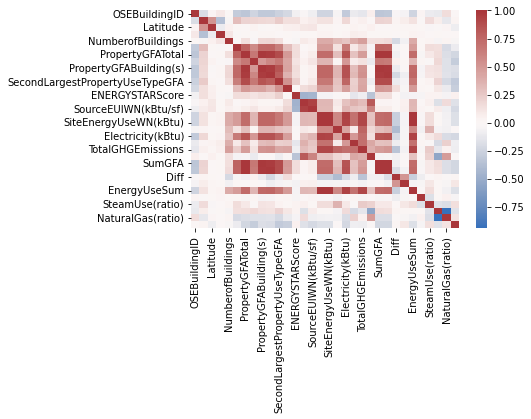

In [134]:
# Regarder les corrélations entre les variables
sns.heatmap(selected_data.corr(), center=0, cmap='vlag')

In [135]:
selected_data.columns

Index(['OSEBuildingID', 'PrimaryPropertyType', 'PropertyName',
       'CouncilDistrictCode', 'Neighborhood', 'Latitude', 'Longitude',
       'NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal',
       'PropertyGFAParking', 'PropertyGFABuilding(s)',
       'ListOfAllPropertyUseTypes', 'LargestPropertyUseType',
       'LargestPropertyUseTypeGFA', 'SecondLargestPropertyUseType',
       'SecondLargestPropertyUseTypeGFA', 'ThirdLargestPropertyUseType',
       'ThirdLargestPropertyUseTypeGFA', 'ENERGYSTARScore',
       'SiteEUIWN(kBtu/sf)', 'SourceEUIWN(kBtu/sf)', 'SiteEnergyUse(kBtu)',
       'SiteEnergyUseWN(kBtu)', 'SteamUse(kBtu)', 'Electricity(kBtu)',
       'NaturalGas(kBtu)', 'TotalGHGEmissions', 'GHGEmissionsIntensity',
       'SumGFA', 'Sum_UT_GFA', 'Diff', 'Ratio', 'EnergyUseSum',
       'DiffEnergyUse', 'SteamUse(ratio)', 'Electricity(ratio)',
       'NaturalGas(ratio)', 'Age'],
      dtype='object')

In [136]:
# Sélectionner les features à analyser
df_final = selected_data[['OSEBuildingID', 'PrimaryPropertyType', 'CouncilDistrictCode', 'Neighborhood', 'NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal', 'PropertyGFAParking', 'PropertyGFABuilding(s)', 'ENERGYSTARScore', 'SiteEUIWN(kBtu/sf)', 'GHGEmissionsIntensity', 'SteamUse(ratio)', 'Electricity(ratio)', 'NaturalGas(ratio)', 'Age']]

<AxesSubplot:>

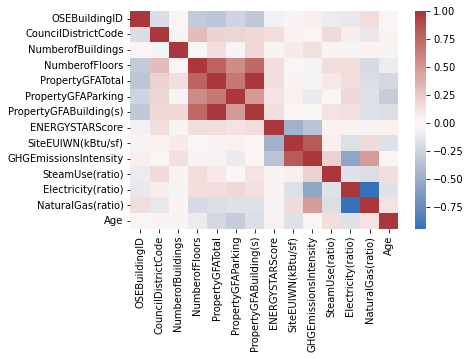

In [137]:
sns.heatmap(df_final.corr(), center=0, cmap='vlag')

In [138]:
# Feature selection des features numériques
X = df_final.drop(['OSEBuildingID', 'PrimaryPropertyType', 'Neighborhood', 'ENERGYSTARScore', 'GHGEmissionsIntensity', 'SiteEUIWN(kBtu/sf)'], axis = 1)

In [139]:
y_emission = df_final['GHGEmissionsIntensity']
y_energy_use = df_final['SiteEUIWN(kBtu/sf)']

In [140]:
from sklearn.feature_selection import f_regression, SelectKBest

In [141]:
selector_emission = SelectKBest(score_func=f_regression, k='all')

In [142]:
selector_emission.fit_transform(X, y_emission)

array([[7.00000000e+00, 1.00000000e+00, 1.20000000e+01, ...,
        5.46059968e-01, 1.76638397e-01, 8.90000000e+01],
       [7.00000000e+00, 1.00000000e+00, 1.10000000e+01, ...,
        3.86609073e-01, 6.13390927e-01, 2.00000000e+01],
       [7.00000000e+00, 1.00000000e+00, 4.10000000e+01, ...,
        6.82307462e-01, 2.05794375e-02, 4.70000000e+01],
       ...,
       [2.00000000e+00, 1.00000000e+00, 1.00000000e+00, ...,
        4.17295647e-01, 5.82704353e-01, 1.20000000e+01],
       [1.00000000e+00, 1.00000000e+00, 1.00000000e+00, ...,
        4.84898057e-01, 5.15101943e-01, 2.70000000e+01],
       [2.00000000e+00, 1.00000000e+00, 1.00000000e+00, ...,
        3.75189226e-01, 6.24810774e-01, 7.80000000e+01]])

In [143]:
selector_emission.scores_

array([5.62912352e-02, 2.32923995e+01, 4.36745771e+00, 2.83478270e+00,
       1.56434380e+01, 7.33542294e-01, 6.00733721e+01, 5.76653070e+02,
       3.88412687e+02, 5.18768191e-01])

Text(0.5, 1.0, 'Score des différentes variables pour la prédiction de GHGEmissionsIntensity')

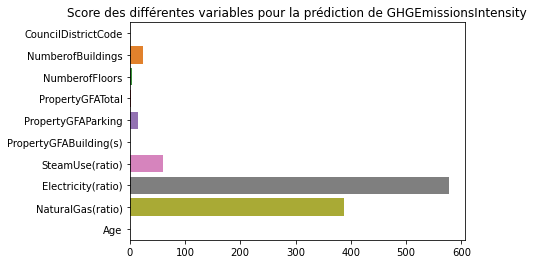

In [144]:
sns.barplot(x=selector_emission.scores_, y=X.columns)
plt.title('Score des différentes variables pour la prédiction de GHGEmissionsIntensity')

Features pour la prédiction de GHGEmissionsIntensity
data_GHGE = df_final[['PrimaryPropertyType', 'Neighborhood', 'NumberofBuildings', 'NumberofFloors', 'PropertyGFAParking', 'SteamUse(ratio)',
       'Electricity(ratio)', 'NaturalGas(ratio)', 'ENERGYSTARScore', 'GHGEmissionsIntensity']]

 Export des données
data_GHGE.to_csv('data_GHGE.csv')

In [145]:
selector_energy_use = SelectKBest(score_func=f_regression, k='all')
selector_energy_use.fit_transform(X, y_energy_use)

array([[7.00000000e+00, 1.00000000e+00, 1.20000000e+01, ...,
        5.46059968e-01, 1.76638397e-01, 8.90000000e+01],
       [7.00000000e+00, 1.00000000e+00, 1.10000000e+01, ...,
        3.86609073e-01, 6.13390927e-01, 2.00000000e+01],
       [7.00000000e+00, 1.00000000e+00, 4.10000000e+01, ...,
        6.82307462e-01, 2.05794375e-02, 4.70000000e+01],
       ...,
       [2.00000000e+00, 1.00000000e+00, 1.00000000e+00, ...,
        4.17295647e-01, 5.82704353e-01, 1.20000000e+01],
       [1.00000000e+00, 1.00000000e+00, 1.00000000e+00, ...,
        4.84898057e-01, 5.15101943e-01, 2.70000000e+01],
       [2.00000000e+00, 1.00000000e+00, 1.00000000e+00, ...,
        3.75189226e-01, 6.24810774e-01, 7.80000000e+01]])

Text(0.5, 1.0, 'Score des différentes variables pour la prédiction de SiteEUIWN(kBtu/sf)')

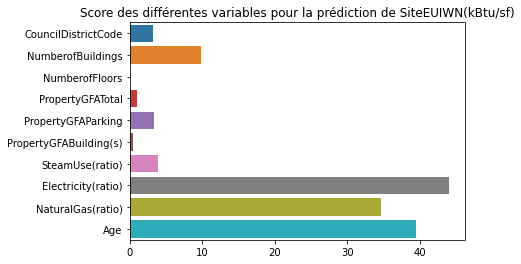

In [146]:
sns.barplot(x=selector_energy_use.scores_, y=X.columns)
plt.title('Score des différentes variables pour la prédiction de SiteEUIWN(kBtu/sf)')

In [147]:
# Features à supprimer pour les cibles
deletion = ['CouncilDistrictCode', 'NumberofFloors', 'PropertyGFATotal', 'PropertyGFABuilding(s)']

 Features pour la prédiction de SiteEUIWN(kBtu/sf)
data_Energy = df_final[['PrimaryPropertyType', 'Neighborhood', 'CouncilDistrictCode', 'NumberofBuildings', 'PropertyGFAParking', 'SteamUse(ratio)',
       'Electricity(ratio)', 'NaturalGas(ratio)', 'ENERGYSTARScore', 'SiteEUIWN(kBtu/sf)']]

 Export des données
data_Energy.to_csv('data_Energy.csv')

In [148]:
# Pour la prédiction de GHGEmissions enlever la feature age

In [149]:
# Merge le dataframe selected_data avec les données de property use type encodées
df_global = df_final.merge(encoded_type, how='inner', copy=False, on='OSEBuildingID')

In [150]:
df_global.columns

Index(['OSEBuildingID', 'PrimaryPropertyType', 'CouncilDistrictCode',
       'Neighborhood', 'NumberofBuildings', 'NumberofFloors',
       'PropertyGFATotal', 'PropertyGFAParking', 'PropertyGFABuilding(s)',
       'ENERGYSTARScore', 'SiteEUIWN(kBtu/sf)', 'GHGEmissionsIntensity',
       'SteamUse(ratio)', 'Electricity(ratio)', 'NaturalGas(ratio)', 'Age',
       'Adult Education', 'Automobile Dealership', 'Bank Branch',
       'College/University', 'Courthouse', 'Data Center',
       'Distribution Center', 'Financial Office', 'Fire Station',
       'Fitness Center/Health Club/Gym',
       'Hospital (General Medical & Surgical)', 'Hotel', 'K-12 School',
       'Laboratory', 'Library', 'Lifestyle Center',
       'Manufacturing/Industrial Plant', 'Medical Office', 'Movie Theater',
       'Multifamily Housing', 'Museum', 'Non-Refrigerated Warehouse', 'Office',
       'Other', 'Other - Education', 'Other - Entertainment/Public Assembly',
       'Other - Lodging/Residential', 'Other - Mall',
 

In [151]:
df_clean = df_global.drop(axis=1, labels=deletion)

In [152]:
df_clean = df_global.drop(axis=1, labels='OSEBuildingID')

In [153]:
df_clean.columns

Index(['PrimaryPropertyType', 'CouncilDistrictCode', 'Neighborhood',
       'NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal',
       'PropertyGFAParking', 'PropertyGFABuilding(s)', 'ENERGYSTARScore',
       'SiteEUIWN(kBtu/sf)', 'GHGEmissionsIntensity', 'SteamUse(ratio)',
       'Electricity(ratio)', 'NaturalGas(ratio)', 'Age', 'Adult Education',
       'Automobile Dealership', 'Bank Branch', 'College/University',
       'Courthouse', 'Data Center', 'Distribution Center', 'Financial Office',
       'Fire Station', 'Fitness Center/Health Club/Gym',
       'Hospital (General Medical & Surgical)', 'Hotel', 'K-12 School',
       'Laboratory', 'Library', 'Lifestyle Center',
       'Manufacturing/Industrial Plant', 'Medical Office', 'Movie Theater',
       'Multifamily Housing', 'Museum', 'Non-Refrigerated Warehouse', 'Office',
       'Other', 'Other - Education', 'Other - Entertainment/Public Assembly',
       'Other - Lodging/Residential', 'Other - Mall',
       'Other - Public Se

In [154]:
# Exporter le df
df_clean.to_csv('data_clean.csv')

In [155]:
df_clean.shape

(1317, 68)

In [156]:
# Créer un dataframe avec uniquement les bâtiments pour lesquels le energystarscore est donné
df_energy_star_score = df_clean.dropna(how='any', subset=['ENERGYSTARScore'])

In [157]:
df_energy_star_score.isna().sum().sum()

0

In [158]:
# Exporter le dataframe
df_energy_star_score.to_csv('df_energy_star_score.csv')